# Recall prediction in DARTH+

## Imports

In [50]:
import os
import json
import time
import math

import numpy as np
import pandas as pd
import lightgbm as lgb
import dask.dataframe as dd

from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

DATASET_PARAMS = {
    "SIFT100M": {
        "M": 32,
        "efC": 500,
        "efS": 500,
        "color": "lightblue",
        "label": "SIFT100M",
    },
    "SIFT10M": {
        "M": 32,
        "efC": 500,
        "efS": 500,
        "color": "lightblue",
        "label": "SIFT10M",
    },
    "GIST1M": {
        "M": 32,
        "efC": 500,
        "efS": 1000,
        "color": "lightgreen",
        "label": "GIST1M",
    },
    "GLOVE100": {
        "M": 16,
        "efC": 500,
        "efS": 500,
        "color": "orange",
        "label": "GLOVE1M",
    },
    "DEEP100M": {
        "M": 32,
        "efC": 500,
        "efS": 750,
        "color": "plum",
        "label": "DEEP100M",
    },
    "DEEP10M": {
        "M": 16,
        "efC": 500,
        "efS": 750,
        "color": "plum",
        "label": "DEEP10M",
    },
    "T2I100M": {
        "M": 80,
        "efC": 1000,
        "efS": 2500,
        "color": "rosybrown",
        "label": "T2I100M",
    },
    "T2I10M": {
        "M": 40,
        "efC": 1000,
        "efS": 1500,
        "color": "rosybrown",
        "label": "T2I10M",
    },
}

SEED = 42

DARTH_FEATS = (
    ["step", "dists", "inserts"]
    + ["first_nn_dist", "nn_dist", "furthest_dist"]
    + ["avg_dist", "variance", "percentile_25", "percentile_50", "percentile_75"]
)

QUERY_DIMS_FEATS = [
    "q_dim_avg",
    "q_dim_std",
    "q_dim_min",
    "q_dim_max",
    "q_dim_median",
    "q_dim_l1",
    "q_dim_l2",
    "q_dim_range",
]

COLUMNS_TO_LOAD = (
    ["qid", "elaps_ms"]
    + DARTH_FEATS
    + QUERY_DIMS_FEATS
    + ["r", "feats_collect_time_ms"]
)

FEATURE_CLASSES = {
    "darth_feats": DARTH_FEATS,
    "darth_and_query_dims": DARTH_FEATS + QUERY_DIMS_FEATS,
}

DARTH_PLUS_JSON_DIRECTORY = "./../../experiments/darth_plus_jsons/"
if not os.path.exists(DARTH_PLUS_JSON_DIRECTORY):
    os.makedirs(DARTH_PLUS_JSON_DIRECTORY, exist_ok=True)
    
DARTH_JSON_DIRECTORY = "./../../experiments/generated_json/"
if not os.path.exists(DARTH_JSON_DIRECTORY):
    os.makedirs(DARTH_JSON_DIRECTORY, exist_ok=True)

DARTH_PLUS_MODEL_DIRECTORY = "./../../predictor_models/darth_plus/"
DARTH_MODEL_DIRECTORY = "./../../predictor_models/darth/"


def get_dataset_name(M, efC, efS, num_queries, ds_name, k, logint):
    return f"/data/mchatzakis/et_training_data/early-stop-training/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{num_queries}_li{logint}.txt"


def get_dataset_name_darthplus(M, efC, efS, num_queries, ds_name, k):
    return f"/data/mchatzakis/et_training_data/darth_plus/darth-plus-training/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{num_queries}.txt"


def get_testing_dataset_name(M, efC, efS, query_num, ds_name, k):
    return f"../../experiments/results/darth_journal/testing_dp_logging/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{query_num}_li{1}.txt"


def get_testing_dataset_name_inner_product(M, efC, efS, query_num, ds_name, k):
    return f"../../experiments/results/darth_journal/testing_dp_logging/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{query_num}_li{1}_inner-product.txt"


def get_validation_dataset_name(M, efC, efS, query_num, ds_name, k):
    return f"../../experiments/results/darth_journal/validation_dp_logging/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{query_num}_li{1}.txt"


def get_validation_dataset_name_inner_product(M, efC, efS, query_num, ds_name, k):
    return f"../../experiments/results/darth_journal/validation_dp_logging/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{query_num}_li{1}_inner-product.txt"

def get_calibration_dataset_name(M, efC, efS, query_num, ds_name, k):
    return f"../../experiments/results/darth_journal/calibration_logging/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{query_num}.txt"


def train_lgb_regression(X, y, n_estimators=100):
    model = lgb.LGBMRegressor(
        objective="regression",
        random_state=SEED,
        n_estimators=n_estimators,
        verbose=-1,
    )
    model_train_time_start = time.time()
    model.fit(X, y)
    model_train_time = time.time() - model_train_time_start

    return model, model_train_time


def train_lgb_quantile(X, y, quantile, n_estimators=100):
    model = lgb.LGBMRegressor(
        objective="quantile",
        alpha=quantile,
        random_state=SEED,
        n_estimators=n_estimators,
        verbose=-1,
    )
    model_train_time_start = time.time()
    model.fit(X, y)
    model_train_time = time.time() - model_train_time_start

    return model, model_train_time


def dd_load_as_pd(df_path, columns_to_load=None):
    dd_df = dd.read_csv(
        df_path,
        usecols=columns_to_load,
    )
    pd_df = dd_df.compute()
    return pd_df


def dp_find_pi_params(data_df, target_recalls=[0.80, 0.85, 0.90, 0.95, 0.99]):
    grouped_by_query = data_df.groupby("qid")
    k_results = {}

    for target_recall in target_recalls:
        distance_calcs_to_reach_target_recall = []

        for idx, group in grouped_by_query:
            group = group[group["r"] >= target_recall]
            if not group.empty:
                row_of_first_reached_recall = group.iloc[0]
                distance_calcs_to_reach_target_recall.append(row_of_first_reached_recall["dists"])

        mean_dists = np.mean(distance_calcs_to_reach_target_recall)
        max_dists = np.max(distance_calcs_to_reach_target_recall)
        min_dists = np.min(distance_calcs_to_reach_target_recall)

        # raw values
        ipi_raw = mean_dists / 2
        mpi_raw = mean_dists / 10

        # pad up to nearest multiple of 20
        ipi = int(np.ceil(ipi_raw / 20) * 20)
        mpi = int(np.ceil(mpi_raw / 20) * 20)

        k_results[target_recall] = {
            "avg": mean_dists,
            "max": max_dists,
            "min": min_dists,
            "ipi": ipi,
            "mpi": mpi,
        }

    return k_results



def get_baseline_results_filename(M, efC, efS, s, ds_name, k, r_target):
    return f"../../experiments/results/naive-early-stop-testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}_tr{float(r_target):.2f}.txt"


def get_no_early_stop_dataset_name(M, efC, efS, s, ds_name, k):
    return f"../../experiments/results/no-early-stop/testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}.txt"


def get_laet_results_filename(M, efC, efS, s, ds_name, k, r_target):
    return f"../../experiments/results/laet-early-stop-testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}_tr{float(r_target):.2f}.txt"


def get_rem_results_filename(M, efC, efS, s, ds_name, k, r_target):
    return f"../../experiments/results/classic-hnsw/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}_tr{float(r_target):.2f}.txt"


def get_optimal_early_stop_testing_dataset_name(M, efC, efS, s, ds_name, k):
    return f"../../experiments/results/no-early-stop/testing/{ds_name}/k{k}/detailed.M{M}_efC{efC}_efS{efS}_qs{s}.txt"


def get_darth_results_filename(M, efC, efS, s, ds_name, k, r_target, ipi, mpi):
    return f"../../experiments/results/early-stop-testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}_tr{float(r_target):.2f}_ipi{ipi}_mpi{mpi}.txt"


def get_darth_plus_classic_regression_results_filename(M, efC, efS, s, ds_name, k, r_target, ipi, mpi):
    return f"../../experiments/results/darth_journal/darth-plus-testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}_tr{float(r_target):.2f}_ipi{ipi}_mpi{mpi}_noconf.txt"


def get_darth_plus_classic_regression_conformal_results_filename(M, efC, efS, s, ds_name, k, r_target, ipi, mpi, expcov):
    return f"../../experiments/results/darth_journal/darth-plus-testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}_tr{float(r_target):.2f}_ipi{ipi}_mpi{mpi}_expcov{float(expcov):.2f}.txt"


def get_darth_plus_quantile_regression_results_filename(M, efC, efS, s, ds_name, k, r_target, ipi, mpi, lq):
    return f"../../experiments/results/darth_journal/darth-plus-testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}_tr{float(r_target):.2f}_ipi{ipi}_mpi{mpi}_noconf_lq{lq}.txt"


def avg_recall_calculator(df, s, r_target, recall_col="r"):
    return np.mean(df[recall_col])

def rqut_calculator(df, s, r_target, recall_col="r"):
    recalls = df[recall_col].round(2)
    rqut = len(recalls[recalls < r_target]) / s
    return rqut
    
def rde_calculator(df, s, r_target, recall_col="r"):
    return df["RDE"].mean()

def tde_calculator(df, s, r_target, recall_col="r"):
    return df["TDR"].mean()

def nrs_rev_calculator(df, s, r_target, recall_col="r"):
    return 1/df["NRS"].mean()

def time_calculator(df, s, r_target, recall_col="r"):
    return df["elaps_ms"].mean()

def dist_calculation(df, s, r_target, recall_col="r"):
    return df["dists"].mean()

def p99_calculation(df, s, r_target, recall_col="r"):
    below_df = df[df[recall_col] < r_target]
    error = np.abs(below_df[recall_col] - r_target)
    return np.percentile(error, 99)

def error_mean_calculation(df, s, r_target, recall_col="r"):
    below_df = df[df[recall_col] < r_target]    
    errors = abs(below_df[recall_col] - r_target)
    return np.mean(errors)

def worst_errors_calculation(df, s, r_target, recall_col="r"):
    below_df = df[df[recall_col] < r_target]   
    return below_df[recall_col].max()

def worst_1perc_errors_mean_calculation(df, s, r_target, recall_col="r"):
    below_df = df[df[recall_col] < r_target].copy()
    below_df["error"] = abs(r_target - below_df[recall_col])
    sorted_below_df = below_df.sort_values(by="error", ascending=False)    
    num_entries = len(sorted_below_df)
    worst_1_percent_count = max(1, int(0.01 * num_entries))  # At least 1 entry    
    worst_1_perc_mean = sorted_below_df["error"].head(worst_1_percent_count).mean()
    
    return worst_1_perc_mean

def qps_calculator(df, s, r_target, recall_col="r"):
    average_time_ms = df["elaps_ms"].mean()
    average_time_seconds = average_time_ms / 1000
    qps = 1 / average_time_seconds
    return qps

  
quality_measures = {
    "RQUT": {
        "label": "RQUT",
        "calculator": rqut_calculator,
        "type": "bar"
    },
    "RDE": {
        "label": "RDE",
        "calculator": rde_calculator,
        "type": "bar"
    },
    "TDR": {
        "label": "TDR",
        "calculator": tde_calculator,
        "type": "bar"
    },
    "NRS_rev": {
        "label": r"$NRS^{-1}$",
        "calculator": nrs_rev_calculator,
        "type": "bar"
    },
    "Time": {
        "label": "Time (ms)",
        "calculator": time_calculator,
        "type": "line"
    },
    "Dist": {
        "label": "Dists",
        "calculator": dist_calculation,
        "type": "line"
    },
    "p99": {
        "label": r"$P99$",
        "calculator": p99_calculation,
        "type": "bar"
    },
    "Worst1perc": {
        "label": "Worst 1%",
        "calculator": worst_1perc_errors_mean_calculation,
        "type": "bar"
    },
    "QPS": {
        "label": "QPS",
        "calculator": qps_calculator,
        "type": "line"
    },
    "avgRecall": {
        "label": "Actual Recall",
        "calculator": avg_recall_calculator,
        "type": "line"
    },
    "avgError": {
        "label": "Avg. Error",
        "calculator": error_mean_calculation,
        "type": "bar"
    }
}

algorithm_conf = {
    "baseline": {
        "color": "black",
        "label": "Baseline",
        "marker": "s"
    },
    "rem": {
        "color": "lightgray",
        "marker": "^",
        "label": "REM",
    },
    "laet": {
        "color": "gray",
        "marker": "x",
        "label": "LAET",
    },
    "darth": {
        "color": "tomato",
        "marker": "o",
        "label": "DARTH",
    },
    
    "darth+_classic": {
        "color": "mediumpurple",
        "marker": "o",
        "label": "DARTH+",
    },
    "darth+_quant_lq0.1_uq0.9": {
        "color": "royalblue",
        "marker": "o",
        "label": "DARTH+_[0.1,0.9]",
    },
    "darth+_quant_lq0.1": {
        "color": "royalblue",
        "marker": "o",
        "label": "DARTH+ g.=0.1 (quan)",
    },
    "darth+_quant_lq0.05_uq0.95": {
        "color": "royalblue",
        "marker": "o",
        "label": "DARTH+_[0.05,0.95]",
    },
    "darth+_quant_lq0.05": {
        "color": "royalblue",
        "marker": "o",
        "label": "DARTH+_0.05",
    },
    "darth+_classic_cov_0.9": {
      "color": "mediumseagreen",
      "marker": "o",
      "label": "DARTH+ g.=0.1 (conf)",
    },
    "darth+_classic_cov_0.95": {
      "color": "mediumseagreen",
      "marker": "o",
      "label": "DARTH+_cov0.95"
    },
    "darth+_classic_cov_0.8": {
      "color": "mediumseagreen",
      "marker": "o",
      "label": "DARTH+_cov0.8"
    },
    "no_early_stop": {
        "color": "darkgreen",
        "marker": "D",
        "label": "Plain HNSW",
    },
    "darth+_quant_lq0.2": {
        "color": "royalblue",
        "marker": "o",
        "label": "DARTH+ g.=0.2 (quan)",
    },
    
}

variant_dp_colors = ["dark_salmon", "chocolate", "sienna", "saddlebrown", "sandybrown", "peachpuff"]



In [ ]:
# legend plots
plt.rcParams.update({"font.size": 48})

from matplotlib.patches import Patch

fig_legend, ax_legend = plt.subplots(figsize=(8, 1))  # Adjust the figsize for better alignment
legend_elements = [
    Patch(facecolor=algorithm_conf[alg]["color"], edgecolor=algorithm_conf[alg]["color"], alpha=0.8, label=algorithm_conf[alg]["label"]) for alg in ["darth", "darth+_classic"]
]
ax_legend.legend(handles=legend_elements, loc='center', ncol=4, frameon=False)
ax_legend.axis('off')
savefile = f"./../../experiments/plots/darth_journal/legend_darth_darthp.pdf"
fig_legend.savefig(savefile, bbox_inches="tight")
print("Saved legend at ", savefile)
plt.show()

In [ ]:
plt.rcParams.update({"font.size": 48})

fig_legend, ax_legend = plt.subplots(figsize=(8, 1))
legend_elements = [Patch(facecolor=DATASET_PARAMS[ds_name]["color"], edgecolor=DATASET_PARAMS[ds_name]["color"], alpha=0.8, label=DATASET_PARAMS[ds_name]["label"]) for ds_name in ["SIFT10M", "DEEP10M", "GLOVE100", "GIST1M", "T2I10M"]]
ax_legend.legend(handles=legend_elements, loc='center', ncol=5, frameon=False, handletextpad=0.3,  columnspacing=0.5, labelspacing=0.3 )
ax_legend.axis('off')
fig_legend.savefig(f"./../../experiments/plots/darth_journal/legend_datasets_10M.pdf", bbox_inches="tight")
print("Saved legend at ", f"./../../experiments/plots/darth_journal/legend_datasets_10M.pdf")
plt.show()
plt.close(fig_legend)

In [ ]:
# legend plots guarantees competitors
plt.rcParams.update({"font.size": 48})

from matplotlib.patches import Patch

fig_legend, ax_legend = plt.subplots(figsize=(8, 1))  # Adjust the figsize for better alignment
legend_elements = [
    Patch(facecolor=algorithm_conf[alg]["color"], edgecolor=algorithm_conf[alg]["color"], alpha=0.8, label=algorithm_conf[alg]["label"]) for alg in ["rem", "darth+_classic", "darth+_classic_cov_0.9", "darth+_quant_lq0.1"]
]
ax_legend.legend(handles=legend_elements, loc='center', ncol=5, frameon=False)
ax_legend.axis('off')
savefile = f"./../../experiments/plots/darth_journal/legend_guarantee_competitors.pdf"
fig_legend.savefig(savefile, bbox_inches="tight")
print("Saved legend at ", savefile)
plt.show()

## Analysis of the DARTH+ training data and parameter reccomendation

In [ ]:
training_queries_num = 10000
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M"]
target_recalls = [0.80, 0.85, 0.90, 0.95, 0.99]

data = "training"  # or training, or testing

for ds_name in all_datasets:
    pi_params = {}
    for k in all_k_values:
        M = DATASET_PARAMS[ds_name]["M"]
        efC = DATASET_PARAMS[ds_name]["efC"]
        efS = DATASET_PARAMS[ds_name]["efS"]

        data_path = ""
        if data == "testing":
            data_path = get_testing_dataset_name(
                M, efC, efS, training_queries_num, ds_name, k
            )
        elif data == "calibration":
            data_path = get_calibration_dataset_name(
                M, efC, efS, training_queries_num, ds_name, k
            )
        else:
            data_path = get_dataset_name_darthplus(
                M, efC, efS, training_queries_num, ds_name, k
            )

        data_df = dd_load_as_pd(
            data_path,
            COLUMNS_TO_LOAD,
        )

        y = data_df["r"]
        print(data_df.shape)
        print(np.quantile(y, [0.1, 0.2, 0.8, 0.9, 0.95]))
        
        pi_params[k] = dp_find_pi_params(data_df, target_recalls=target_recalls)
    
    for k in all_k_values:
        print(f"{ds_name}_tuples_k{k}=(")
        for rt in target_recalls:
            ipi = pi_params[k][rt]["ipi"]
            mpi = pi_params[k][rt]["mpi"]
            print(f"    \"{rt:.2f} {ipi} {mpi} {0}\"")
        print(")")  
    print()  
    

## DARTH and DARTH+ model comparison on the validation data

### Training sizes comparison between DARTH and DARTH+

In [27]:
training_queries_num = 10000
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M", "GIST1M", "GLOVE100", "DEEP100M", "T2I100M"]
target_recalls = [0.80, 0.85, 0.90, 0.95, 0.99]

results = {}
for ds_name in all_datasets:
    darth_train_stats = {}
    with open(f"./../../experiments/generated_json/training_results_{ds_name}.json", "r") as f:
        darth_train_stats = json.load(f)
    
    results[ds_name] = {}
    
    for k in all_k_values:
        M = DATASET_PARAMS[ds_name]["M"]
        efC = DATASET_PARAMS[ds_name]["efC"]
        efS = DATASET_PARAMS[ds_name]["efS"]

        li = 1 if ds_name != "T2I100M" else 2
        len_d_df = darth_train_stats[f"{k}"]["10000"][f"{li}"]["all_feats"]["training_data_size"]        
        #d_df = dd_load_as_pd(
        #    get_dataset_name(M, efC, efS, training_queries_num, ds_name, k, li),
        #    ["qid"]
        #)
        #len_d_df = len(d_df)

        dp_data_path = get_dataset_name_darthplus(M, efC, efS, training_queries_num, ds_name, k)
        dp_df = dd_load_as_pd(dp_data_path, ["qid"])
        d_size = len_d_df * len(DARTH_FEATS) * 4  # 4 bytes per float
        dp_size = len(dp_df) * (len(DARTH_FEATS))* 4  # 4 bytes per float
        dp_dims_size = len(dp_df) * (len(DARTH_FEATS) + len(QUERY_DIMS_FEATS)) * 4  # 4 bytes per float
        
        print(f"{ds_name} k={k}: DARTH samples={len_d_df}, DARTH+ samples={len(dp_df)}")
        
        results[ds_name][k] = {
            "darth": {
                "train_samples": len_d_df,
                "train_size_gb": d_size / (1024 * 1024 * 1024),
            },
            "darth_plus": {
                "train_samples": len(dp_df),
                "train_size_gb": dp_size / (1024 * 1024 * 1024),
            },
            "darth_plus_with_query_dims": {
                "train_samples": len(dp_df),
                "train_size_gb": dp_dims_size / (1024 * 1024 * 1024),
            },
        }
        

SIFT100M k=10: DARTH samples=160330651, DARTH+ samples=5315937
SIFT100M k=25: DARTH samples=160180651, DARTH+ samples=10568223
SIFT100M k=50: DARTH samples=159930651, DARTH+ samples=16118902
SIFT100M k=75: DARTH samples=159680651, DARTH+ samples=19747592
SIFT100M k=100: DARTH samples=159430651, DARTH+ samples=22080980
GIST1M k=10: DARTH samples=219264054, DARTH+ samples=9374394
GIST1M k=25: DARTH samples=219114054, DARTH+ samples=17313880
GIST1M k=50: DARTH samples=218864054, DARTH+ samples=24539671
GIST1M k=75: DARTH samples=218614054, DARTH+ samples=28878296
GIST1M k=100: DARTH samples=218364054, DARTH+ samples=31535243
GLOVE100 k=10: DARTH samples=61601007, DARTH+ samples=1676867
GLOVE100 k=25: DARTH samples=61451007, DARTH+ samples=2308509
GLOVE100 k=50: DARTH samples=61201007, DARTH+ samples=2795660
GLOVE100 k=75: DARTH samples=60951007, DARTH+ samples=3252834
GLOVE100 k=100: DARTH samples=60701007, DARTH+ samples=3834954
DEEP100M k=10: DARTH samples=221445618, DARTH+ samples=6971

Saved figure to ./../../experiments/plots/darth_journal/train_samples_SIFT100M.pdf


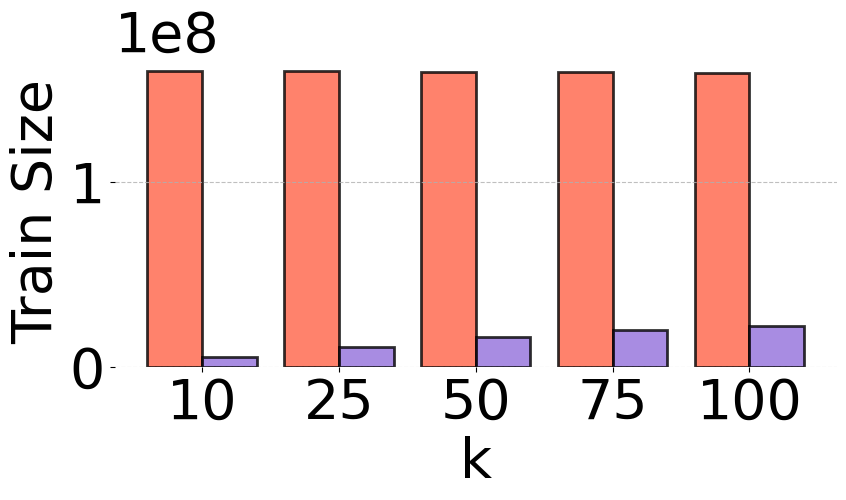

Saved figure to ./../../experiments/plots/darth_journal/train_samples_GIST1M.pdf


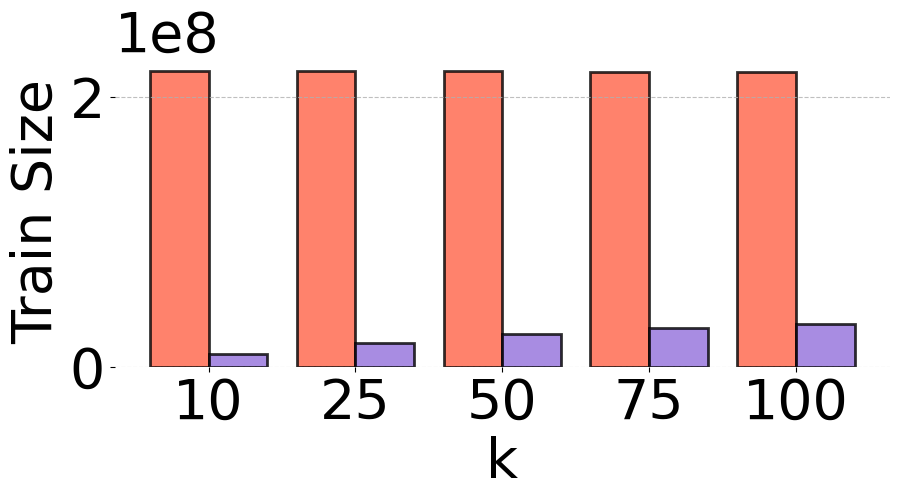

Saved figure to ./../../experiments/plots/darth_journal/train_samples_GLOVE100.pdf


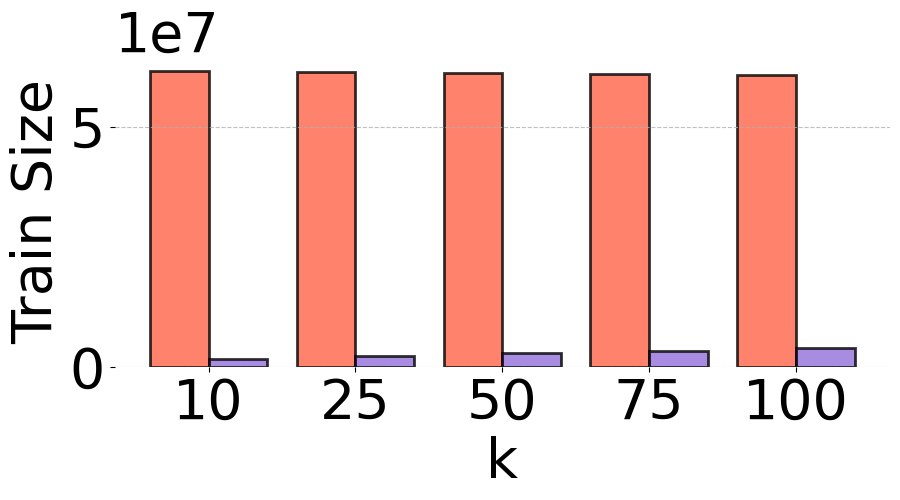

Saved figure to ./../../experiments/plots/darth_journal/train_samples_DEEP100M.pdf


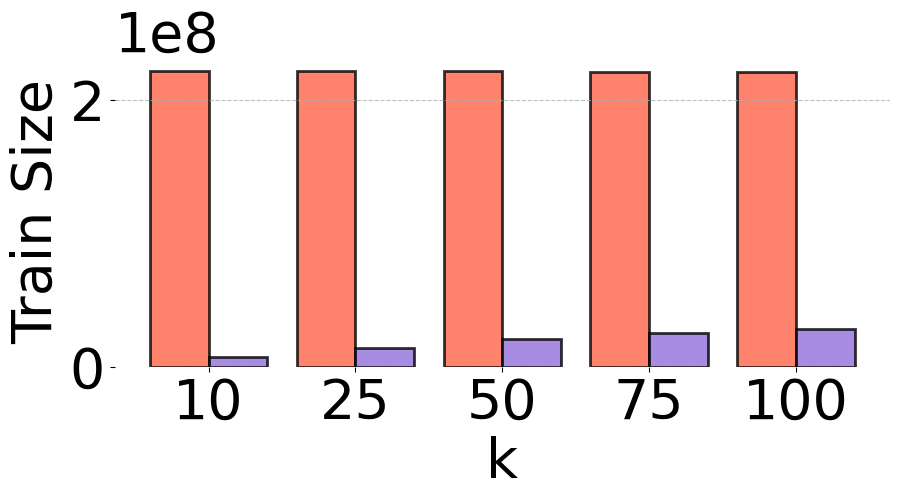

Saved figure to ./../../experiments/plots/darth_journal/train_samples_T2I100M.pdf


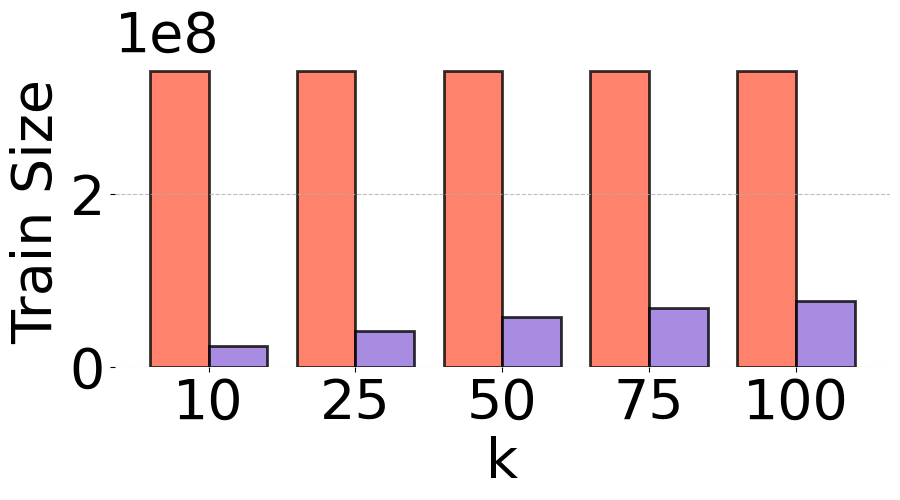

<Figure size 600x80 with 0 Axes>


Best model summary for measure = train_samples
SIFT100M: darth_plus_with_query_dims is 10.83x better than darth (avg over k)
GIST1M: darth_plus_with_query_dims is 9.80x better than darth (avg over k)
GLOVE100: darth_plus_with_query_dims is 22.06x better than darth (avg over k)
DEEP100M: darth_plus_with_query_dims is 11.64x better than darth (avg over k)
T2I100M: darth_plus_with_query_dims is 6.42x better than darth (avg over k)


In [29]:
models_to_compare = ["darth", "darth_plus_with_query_dims"]
measures = ["train_samples"]
all_datasets = ["SIFT100M", "GIST1M", "GLOVE100", "DEEP100M", "T2I100M"]
all_k_values = [10, 25, 50, 75, 100]
generate_unified_plot = False

measure_label = {
    "train_samples": "Train Size"
}

model_label_conf = {
    "darth": {
        "label": "DARTH",
        "color": "tomato"
    },
    "darth_plus_with_query_dims": {
        "label": "DARTH+",
        "color": "mediumpurple",
    }
}

for measure in measures:
    if generate_unified_plot:
        plt.rcParams.update({'font.size': 11})

        # -----------------------------
        # Unified figure (current setup)
        # -----------------------------
        n_ds = len(all_datasets)
        fig, axs = plt.subplots(nrows=1, ncols=n_ds, figsize=(3 * max(1, n_ds), 3))
        if n_ds == 1:
            axs = [axs]
        axs = axs.flatten()

        legend_handles = None
        legend_labels = None

        for ds_idx, ds_name in enumerate(all_datasets):
            ax = axs[ds_idx]
            x = np.arange(len(all_k_values))
            n_models = len(models_to_compare)
            width = 0.8 / n_models

            for i, model_name in enumerate(models_to_compare):
                vals = [
                    results.get(ds_name, {})
                           .get(k, {})
                           .get(model_name, {})
                           .get(measure, np.nan)
                    for k in all_k_values
                ]
                ax.bar(
                    x + i * width,
                    vals,
                    width=width,
                    label=model_label_conf[model_name]["label"],
                    color=model_label_conf[model_name]["color"],
                    alpha=0.8,
                )

            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

            ax.set_xticks(x + (n_models - 1) * width / 2)
            ax.set_xticklabels(all_k_values)
            ax.set_xlabel("k")
            ax.set_ylabel(measure_label[measure])
            ax.set_title(ds_name)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncols=len(models_to_compare),
            frameon=False,
            bbox_to_anchor=(0.5, 1.05),
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    else:
        # ---------------------------------
        # Separate figure per dataset
        # + one standalone legend figure
        # ---------------------------------
        legend_handles = None
        legend_labels = None
        
        plt.rcParams.update({'font.size': 40})

        for ds_name in all_datasets:
            fig, ax = plt.subplots(figsize=(10, 6))

            x = np.arange(len(all_k_values))
            n_models = len(models_to_compare)
            width = 0.8 / n_models

            for i, model_name in enumerate(models_to_compare):
                vals = [
                    results.get(ds_name, {})
                           .get(k, {})
                           .get(model_name, {})
                           .get(measure, np.nan)
                    for k in all_k_values
                ]
                ax.bar(
                    x + i * width,
                    vals,
                    width=width,
                    label=model_label_conf[model_name]["label"],
                    color=model_label_conf[model_name]["color"],
                    alpha=0.8,
                    linewidth=2,
                    edgecolor="black"
                )

            # capture legend entries once
            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

            ax.set_xticks(x + (n_models - 1) * width / 2)
            ax.set_xticklabels(all_k_values)
            ax.set_xlabel("k")
            ax.set_ylabel(measure_label[measure])
            #ax.set_title(ds_name)
            ax.grid(alpha=0.8, axis='y', linestyle='--')
            for spine in ax.spines.values():
                spine.set_visible(False)
            
            savepath = f"./../../experiments/plots/darth_journal/{measure}_{ds_name}.pdf"
            fig.savefig(savepath, bbox_inches='tight')
            print(f"Saved figure to {savepath}")

            plt.tight_layout()
            plt.show()

        # -----------------------------
        # Standalone legend figure
        # -----------------------------
        fig_legend = plt.figure(figsize=(3 * len(models_to_compare), 0.8))
        fig_legend.legend(
            legend_handles,
            legend_labels,
            loc="center",
            ncols=len(models_to_compare),
            frameon=False,
        )
        fig_legend.tight_layout()
        plt.show()

    
    # ---- BEST MODEL SUMMARY (avg over k, multiplicative improvement) ----
    print(f"\nBest model summary for measure = {measure}")
    for ds_name in all_datasets:
        avg_vals = {}

        for model_name in models_to_compare:
            vals = [
                results.get(ds_name, {}).get(k, {}).get(model_name, {}).get(measure, np.nan)
                for k in all_k_values
            ]
            avg_vals[model_name] = np.nanmean(vals)

        best_model = min(avg_vals, key=avg_vals.get)
        best_val = avg_vals[best_model]

        for other_model, other_val in avg_vals.items():
            if other_model == best_model or np.isnan(other_val) or other_val == 0:
                continue

            times_better = other_val / best_val
            print(
                f"{ds_name}: {best_model} is {times_better:.2f}x better than {other_model} (avg over k)"
            )
    # ---------------------------------------------------------


#### Compare the time it takes to gather the training data

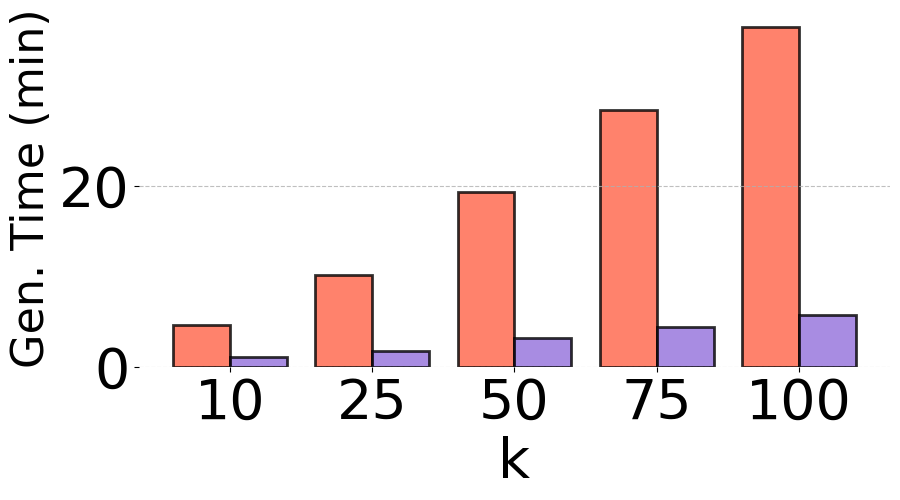

Saved figure to ./../../experiments/plots/darth_journal/gathering_time_SIFT100M.pdf


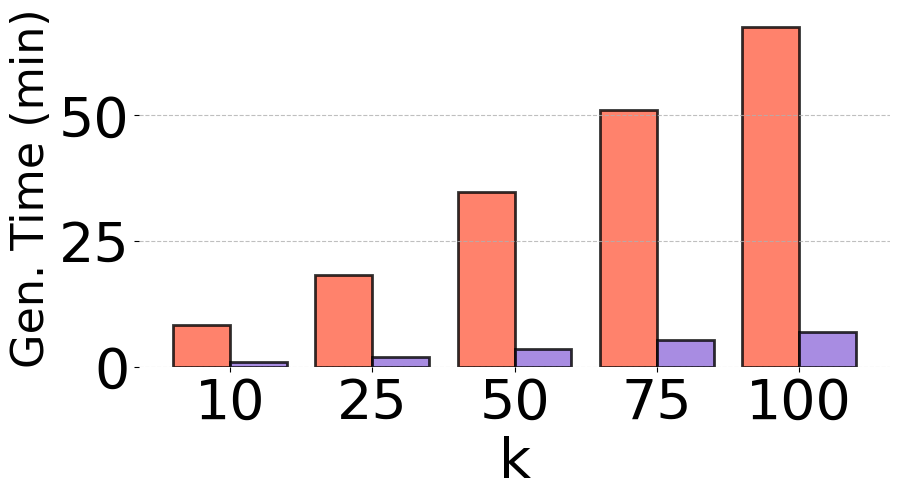

Saved figure to ./../../experiments/plots/darth_journal/gathering_time_GIST1M.pdf


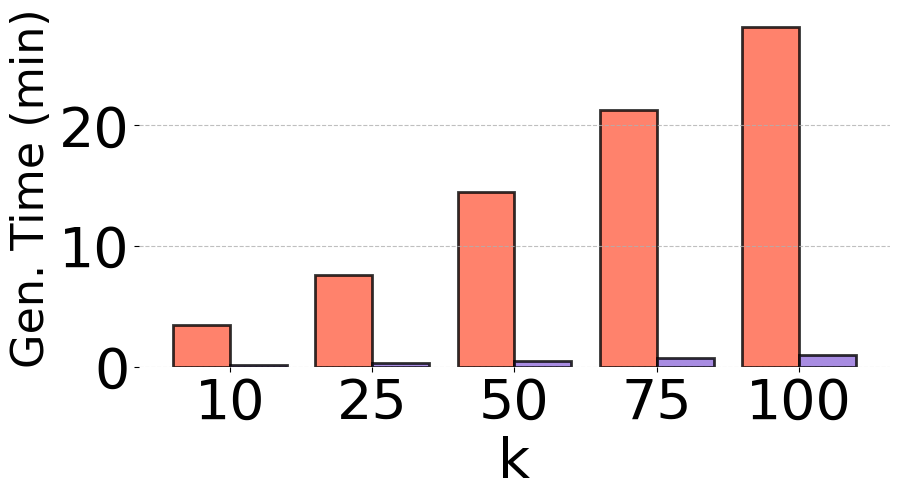

Saved figure to ./../../experiments/plots/darth_journal/gathering_time_GLOVE100.pdf


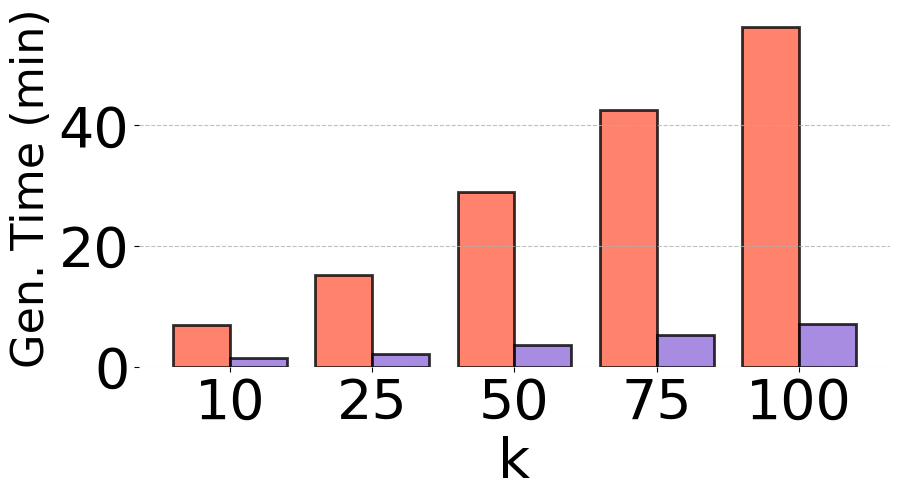

Saved figure to ./../../experiments/plots/darth_journal/gathering_time_DEEP100M.pdf


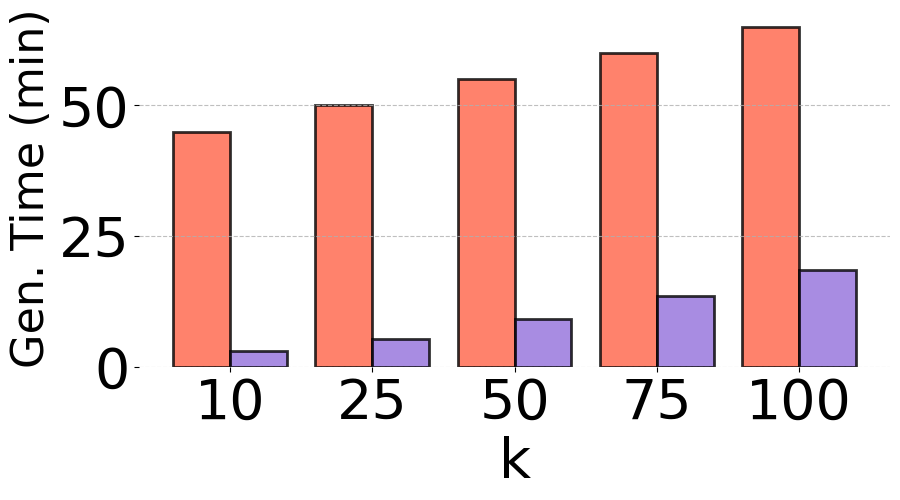

Saved figure to ./../../experiments/plots/darth_journal/gathering_time_T2I100M.pdf


<Figure size 600x80 with 0 Axes>


Best model summary for Data Gathering Time (avg over k)
SIFT100M: darth+_classic is 6.22x better than darth
GIST1M: darth+_classic is 9.71x better than darth
GLOVE100: darth+_classic is 28.45x better than darth
DEEP100M: darth+_classic is 7.71x better than darth
T2I100M: darth+_classic is 5.55x better than darth


In [30]:
darth_gathering_times = {
   "SIFT100M": {
        "k10": 279,
        "k25": 608,
        "k50": 1156,
        "k75": 1704,
        "k100": 2252
    },
    "DEEP100M": {
        "k10": 419,
        "k25": 912,
        "k50": 1734,
        "k75": 2556,
        "k100": 3378
    },
    "GLOVE100": {
        "k10": 209,
        "k25": 456,
        "k50": 867,
        "k75": 1278,
        "k100": 1689
    },
    "GIST1M": {
        "k10": 503,
        "k25": 1095,
        "k50": 2081,
        "k75": 3068,
        "k100": 4054
    },
    "T2I100M": {
        "k10": 2700,
        "k25": 3000,
        "k50": 3300,
        "k75": 3600,
        "k100": 3900
    }
}

darth_plus_gathering_times = {
    "SIFT100M": {
        "k10": 64.36,
        "k25": 107.08,
        "k50": 188.29,
        "k75": 263.83,
        "k100": 340.47,
    },
    "DEEP100M": {
        "k10": 82.313,
        "k25": 130.131,
        "k50": 217.21,
        "k75": 316.48,
        "k100": 421.28,
    },
    "GLOVE100": {
        "k10": 10.3870,
        "k25": 17.27881,
        "k50": 28.191,
        "k75": 42.29,
        "k100": 59.9734,
    },
    "T2I100M": {
        "k10": 182.764,
        "k25": 315.791,
        "k50": 551.4782,
        "k75": 814.07,
        "k100": 1108.21,
    },
    "GIST1M": {
        "k10": 58.351,
        "k25": 111.7023,
        "k50": 205.85,
        "k75": 316.724,
        "k100": 419.51,
    },
}

gathering_times = {
    "darth": darth_gathering_times,
    "darth+_classic": darth_plus_gathering_times,
}

models_to_compare = ["darth", "darth+_classic"]
all_datasets = ["SIFT100M", "GIST1M", "GLOVE100", "DEEP100M", "T2I100M"]
all_k_values = [10, 25, 50, 75, 100]
generate_unified_plot = False

if generate_unified_plot:
    # -----------------------------
    # Unified figure
    # -----------------------------
    n_ds = len(all_datasets)
    fig, axs = plt.subplots(ncols=n_ds, figsize=(4 * max(1, n_ds), 3))
    if n_ds == 1:
        axs = [axs]

    legend_handles = None
    legend_labels = None

    for ds_idx, ds_name in enumerate(all_datasets):
        ax = axs[ds_idx]
        x = np.arange(len(all_k_values))
        n_models = len(models_to_compare)
        width = 0.8 / n_models

        for i, model_name in enumerate(models_to_compare):
            vals = [
                gathering_times.get(model_name, {})
                               .get(ds_name, {})
                               .get(f"k{k}", np.nan) / 60.0
                for k in all_k_values
            ]
            ax.bar(
                x + i * width,
                vals,
                width=width,
                label=algorithm_conf[model_name]["label"],
                color=algorithm_conf[model_name]["color"],
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_xticks(x + (n_models - 1) * width / 2)
        ax.set_xticklabels(all_k_values)
        ax.set_xlabel("k")
        ax.set_ylabel("Generation Time (min)")

    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncols=len(models_to_compare),
        frameon=False,
        bbox_to_anchor=(0.5, 1.05),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

else:
    # ---------------------------------
    # Separate figure per dataset
    # + standalone legend figure
    # ---------------------------------
    legend_handles = None
    legend_labels = None

    for ds_name in all_datasets:
        plt.rcParams.update({'font.size': 40})
        
        fig, ax = plt.subplots(figsize=(10, 6))

        x = np.arange(len(all_k_values))
        n_models = len(models_to_compare)
        width = 0.8 / n_models

        for i, model_name in enumerate(models_to_compare):
            vals = [
                gathering_times.get(model_name, {})
                               .get(ds_name, {})
                               .get(f"k{k}", np.nan) / 60.0
                for k in all_k_values
            ]
            ax.bar(
                x + i * width,
                vals,
                width=width,
                label=algorithm_conf[model_name]["label"],
                color=algorithm_conf[model_name]["color"],
                alpha=0.8,
                linewidth=2,
                edgecolor="black"
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_xticks(x + (n_models - 1) * width / 2)
        ax.set_xticklabels(all_k_values)
        ax.set_xlabel("k")
        ax.set_ylabel("Gen. Time (min)", fontsize=32)
        ax.grid(alpha=0.8, axis='y', linestyle='--')
        for spine in ax.spines.values():
            spine.set_visible(False)

        plt.tight_layout()
        plt.show()
        
        savepath = f"./../../experiments/plots/darth_journal/gathering_time_{ds_name}.pdf"
        fig.savefig(savepath, bbox_inches='tight')
        print(f"Saved figure to {savepath}")

    # -----------------------------
    # Standalone legend figure
    # -----------------------------
    fig_legend = plt.figure(figsize=(3 * len(models_to_compare), 0.8))
    fig_legend.legend(
        legend_handles,
        legend_labels,
        loc="center",
        ncols=len(models_to_compare),
        frameon=False,
    )
    fig_legend.tight_layout()
    plt.show()


# ---- BEST MODEL SUMMARY (avg over k, multiplicative improvement) ----
print("\nBest model summary for Data Gathering Time (avg over k)")
for ds_name in all_datasets:
    avg_vals = {}

    for model_name in models_to_compare:
        vals = [
            gathering_times.get(model_name, {}).get(ds_name, {}).get(f"k{k}", np.nan) / 60.0
            for k in all_k_values
        ]
        avg_vals[model_name] = np.nanmean(vals)

    best_model = min(avg_vals, key=avg_vals.get)
    best_val = avg_vals[best_model]

    for other_model, other_val in avg_vals.items():
        if other_model == best_model or np.isnan(other_val) or other_val == 0:
            continue

        times_better = other_val / best_val
        print(
            f"{ds_name}: {best_model} is {times_better:.2f}x better than {other_model}"
        )

### Comparisons of the DARTH to DARTH+ models and training statistics

In [32]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["T2I100M", "GIST1M", "GLOVE100", "DEEP100M", "SIFT100M"]
n_estimators = 100
data = "validation"

results = {}
for ds_name in all_datasets:
    M = DATASET_PARAMS[ds_name]["M"]
    efC = DATASET_PARAMS[ds_name]["efC"]
    efS = DATASET_PARAMS[ds_name]["efS"]
    
    results[ds_name] = {}
    
    darth_train_stats = {}
    with open(f"./../../experiments/generated_json/training_results_{ds_name}.json", "r") as f:
        darth_train_stats = json.load(f)
    
    darth_plus_train_stats = {}
    with open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"hnsw_{ds_name}_M{M}_efC{efC}_efS{efS}_clTrue_quantFalse_training_results.json"),"r") as f:
        darth_plus_train_stats = json.load(f)
    
    print(darth_plus_train_stats)
    
    for k in all_k_values:
        M = DATASET_PARAMS[ds_name]["M"]
        efC = DATASET_PARAMS[ds_name]["efC"]
        efS = DATASET_PARAMS[ds_name]["efS"]

        data_path = ""
        if data == "testing":
            data_path = get_testing_dataset_name(M, efC, efS, 1000, ds_name, k)
        elif data == "validation":
           data_path = get_validation_dataset_name(M, efC, efS, 1000, ds_name, k)
        else:
            raise ValueError("Data must be either 'testing' or 'validation'")

        li = 1 if ds_name != "T2I100M" else 2
        darth_model = lgb.Booster(
            model_file=os.path.join(
                DARTH_MODEL_DIRECTORY,
                f"{ds_name}_M{M}_efC{efC}_efS{efS}_s10000_k{k}_nestim{n_estimators}_li{li}_all_feats.txt",
            )
        )
        
        darth_plus_model = lgb.Booster(
            model_file=os.path.join(
                DARTH_PLUS_MODEL_DIRECTORY,
                f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_darth_feats_regr_nest{n_estimators}.txt"
            )
        )
        
        darth_plus_with_dims_model = lgb.Booster(
            model_file=os.path.join(
                DARTH_PLUS_MODEL_DIRECTORY,
                f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_darth_and_query_dims_regr_nest{n_estimators}.txt"
            )
        )

        darth_training_time = darth_train_stats[f"{k}"]["10000"][f"{li}"]["all_feats"]["training_time"]        
        darth_plus_training_time = darth_plus_train_stats["training_results"][f"k{k}"]["darth_feats"][f"nest{n_estimators}"]["regression"]["train_time"]
        darth_plus_dims_training_time = darth_plus_train_stats["training_results"][f"k{k}"]["darth_and_query_dims"][f"nest{n_estimators}"]["regression"]["train_time"]
        
        models_to_evaluate = {
            "darth": darth_model,
            "darth+": darth_plus_model,
            "darth+_with_dims": darth_plus_with_dims_model,
        }
        
        training_times = {
            "darth": darth_training_time,
            "darth+": darth_plus_training_time,
            "darth+_with_dims": darth_plus_dims_training_time,
        }
        
        print(data_path)
        data_path = os.path.abspath(data_path)
        data_df = None #dd_load_as_pd(data_path, COLUMNS_TO_LOAD)
        
        #y = data_df["r"]
        #X_d = data_df[FEATURE_CLASSES["darth_feats"]]
        #X_dp = data_df[FEATURE_CLASSES["darth_and_query_dims"]]
        results[ds_name][k] = {}
        for model_name, model in models_to_evaluate.items():
            #X_test = X_d if model_name != "darth+_with_dims" else X_dp
            #y_pred = y#model.predict(X_test)
            mae = 0#mean_absolute_error(y, y_pred)
            mse = 0#mean_squared_error(y, y_pred)
            r2 = 0#r2_score(y, y_pred)
            print(f"    {ds_name} {model_name}, k {k} (mae: {mae:.3f}, mse: {mse:.3f}, r2: {r2:.2f})")
            results[ds_name][k][model_name] = {
                "mae": mae,
                "mse": mse,
                "r2": r2,
                "train_time": training_times[model_name],
                "inference_time": -1,
            }

    

{'training_results': {'k100': {'darth_feats': {'nest100': {'regression': {'train_time': 146.6640772819519, 'feature_importances': [{'Feature': 'first_nn_dist', 'Importance': 559}, {'Feature': 'inserts', 'Importance': 483}, {'Feature': 'nn_dist', 'Importance': 449}, {'Feature': 'variance', 'Importance': 352}, {'Feature': 'percentile_25', 'Importance': 308}, {'Feature': 'step', 'Importance': 221}, {'Feature': 'dists', 'Importance': 161}, {'Feature': 'furthest_dist', 'Importance': 150}, {'Feature': 'percentile_50', 'Importance': 120}, {'Feature': 'percentile_75', 'Importance': 107}, {'Feature': 'avg_dist', 'Importance': 90}]}}}, 'darth_and_query_dims': {'nest100': {'regression': {'train_time': 144.74931979179382, 'feature_importances': [{'Feature': 'first_nn_dist', 'Importance': 283}, {'Feature': 'nn_dist', 'Importance': 278}, {'Feature': 'inserts', 'Importance': 257}, {'Feature': 'percentile_25', 'Importance': 215}, {'Feature': 'q_dim_median', 'Importance': 205}, {'Feature': 'variance', 

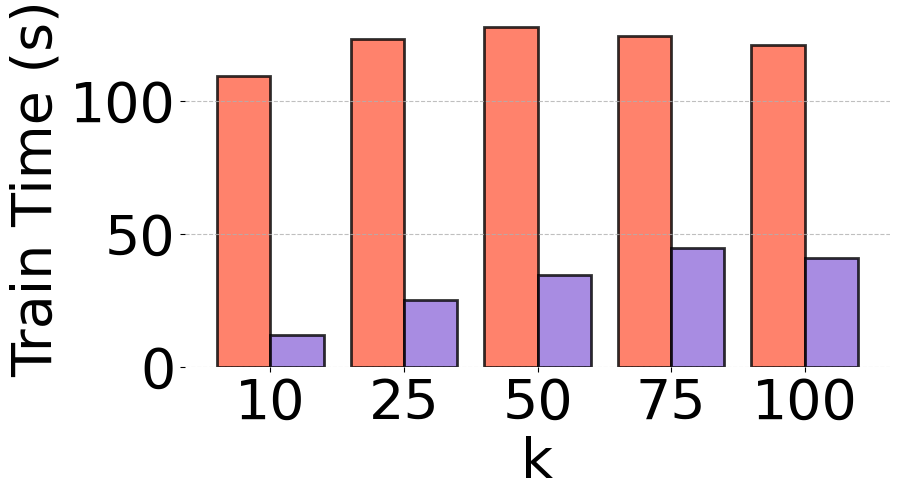

Saved figure to ./../../experiments/plots/darth_journal/training_comparison_train_time_SIFT100M.pdf


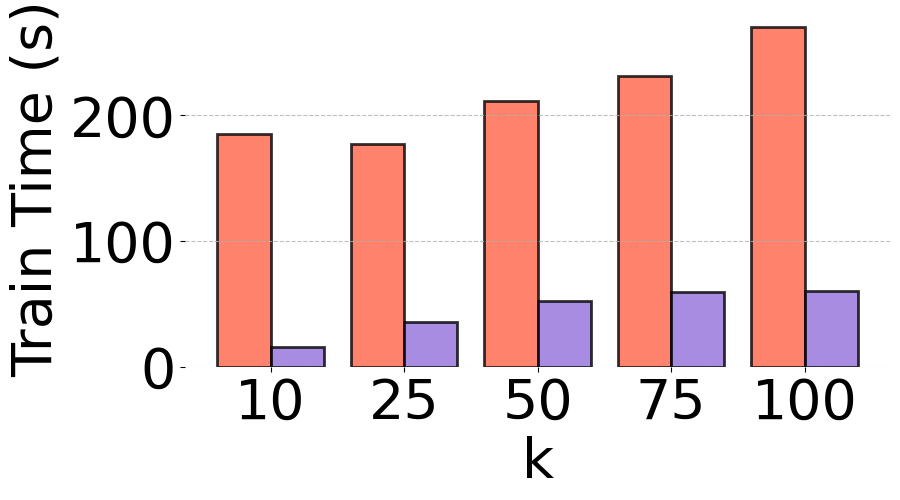

Saved figure to ./../../experiments/plots/darth_journal/training_comparison_train_time_DEEP100M.pdf


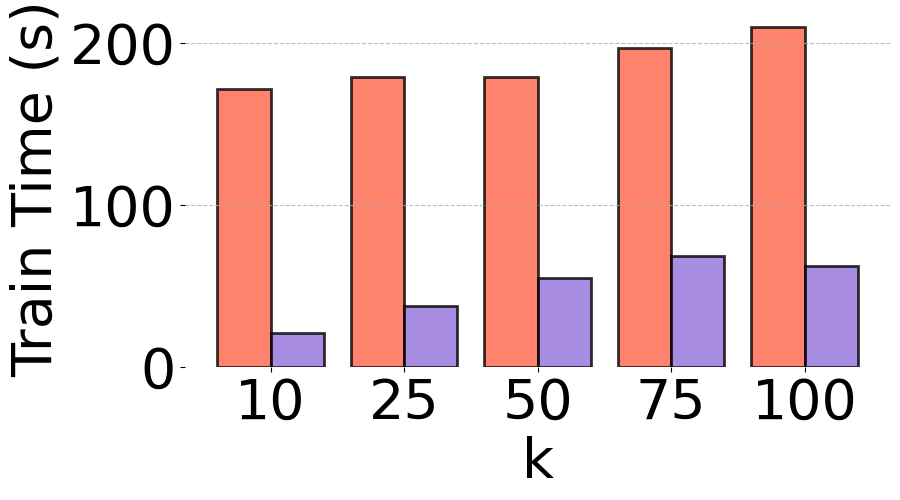

Saved figure to ./../../experiments/plots/darth_journal/training_comparison_train_time_GIST1M.pdf


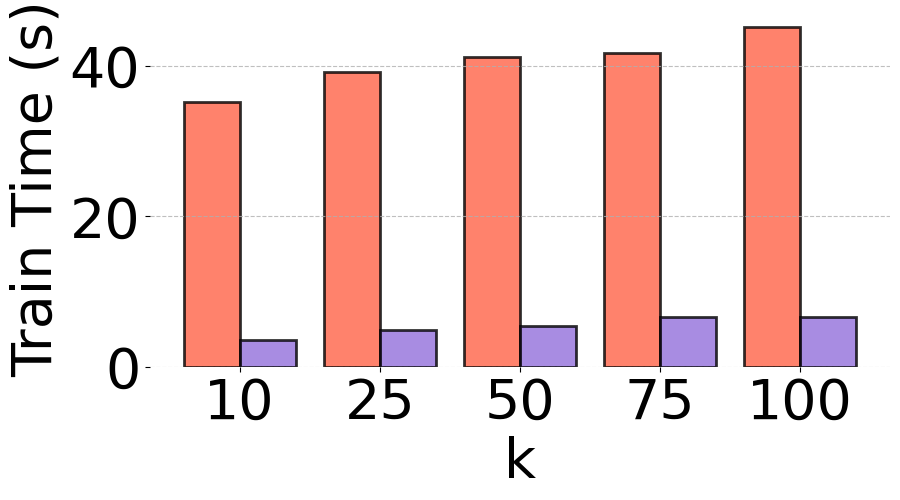

Saved figure to ./../../experiments/plots/darth_journal/training_comparison_train_time_GLOVE100.pdf


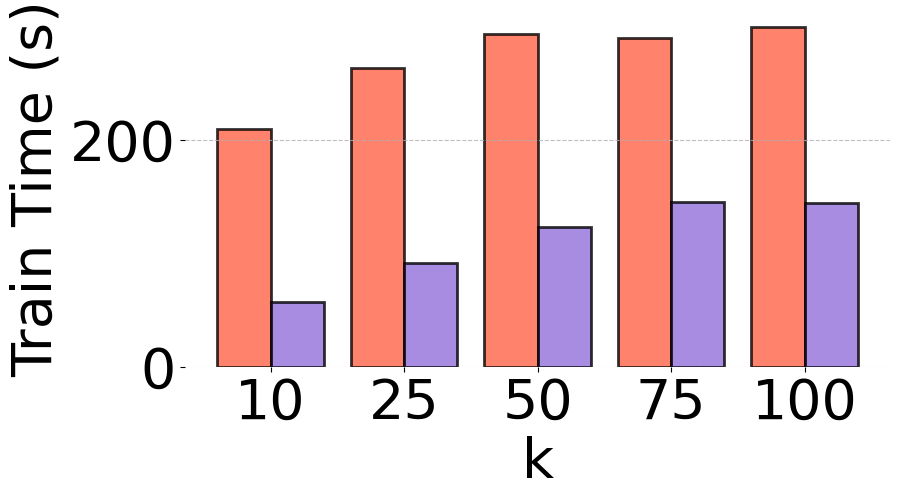

Saved figure to ./../../experiments/plots/darth_journal/training_comparison_train_time_T2I100M.pdf


<Figure size 600x80 with 0 Axes>

In [34]:
models_to_compare = ["darth", "darth+_with_dims"]
measures = ["train_time"]
all_datasets = ["SIFT100M", "DEEP100M", "GIST1M", "GLOVE100", "T2I100M"]
all_k_values = [10, 25, 50, 75, 100]

measure_label = {
    "mae": r"$MAE$",
    "mse": r"$MSE$",
    "r2": r"$R^2$",
    "train_time": "Train Time (s)"
}

model_conf = {
    "darth": {
        "color": "tomato",
        "label": "DARTH"
    },
    "darth+_with_dims":{
        "color": "mediumpurple",
        "label": "DARTH+"
    },
}

results["T2I100M"][10]["darth"]["train_time"] = 210
results["T2I100M"][75]["darth"]["train_time"] = 290
results["T2I100M"][100]["darth"]["train_time"] = 300
results["GIST1M"][100]["darth"]["train_time"] = 210

generate_unified_plot = False  # or False

scale_1e2_measures = {"mae", "mse"}
scale_factor = 100.0
scale_label = r" $(10^2)$"

for measure in measures:

    if generate_unified_plot:
        # -----------------------------
        # Unified figure
        # -----------------------------
        n_ds = len(all_datasets)
        plt.rcParams.update({'font.size': 11})
        fig, axs = plt.subplots(nrows=1, ncols=n_ds, figsize=(3 * max(1, n_ds), 3))
        if n_ds == 1:
            axs = [axs]

        legend_handles = None
        legend_labels = None

        for ds_idx, ds_name in enumerate(all_datasets):
            ax = axs[ds_idx]
            x = np.arange(len(all_k_values))
            n_models = len(models_to_compare)
            width = 0.8 / n_models

            for i, model_name in enumerate(models_to_compare):
                vals = [
                    results.get(ds_name, {})
                           .get(k, {})
                           .get(model_name, {})
                           .get(measure, np.nan)
                    for k in all_k_values
                ]
                if measure in scale_1e2_measures:
                    vals = [v * scale_factor if np.isfinite(v) else v for v in vals]

                ax.bar(
                    x + i * width,
                    vals,
                    width=width,
                    label=model_conf[model_name]["label"],
                    color=model_conf[model_name]["color"],
                )

            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

            ax.set_xticks(x + (n_models - 1) * width / 2)
            ax.set_xticklabels(all_k_values)
            ax.set_xlabel("k")
            if measure in scale_1e2_measures:
                ax.set_ylabel(f"{measure_label[measure]} {scale_label}")
            else:
                ax.set_ylabel(measure_label[measure])
            ax.set_title(ds_name)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

        # unified legend at the top
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncols=len(models_to_compare),
            frameon=False,
            bbox_to_anchor=(0.5, 1.05),
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    else:
        # ---------------------------------
        # Separate figure per dataset
        # + standalone legend figure
        # ---------------------------------
        legend_handles = None
        legend_labels = None

        for ds_name in all_datasets:
            plt.rcParams.update({'font.size': 40})
            fig, ax = plt.subplots(figsize=(10, 6))

            x = np.arange(len(all_k_values))
            n_models = len(models_to_compare)
            width = 0.8 / n_models

            for i, model_name in enumerate(models_to_compare):
                vals = [
                    results.get(ds_name, {})
                           .get(k, {})
                           .get(model_name, {})
                           .get(measure, np.nan)
                    for k in all_k_values
                ]
                if measure in scale_1e2_measures:
                    vals = [v * scale_factor if np.isfinite(v) else v for v in vals]

                ax.bar(
                    x + i * width,
                    vals,
                    width=width,
                    label=model_conf[model_name]["label"],
                    color=model_conf[model_name]["color"],
                    edgecolor="black",
                    alpha=0.8,
                    linewidth=2,
                )

            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

            ax.set_xticks(x + (n_models - 1) * width / 2)
            ax.set_xticklabels(all_k_values)
            ax.set_xlabel("k")
            if measure in scale_1e2_measures:
                ax.set_ylabel(f"{measure_label[measure]} {scale_label}")
            else:
                ax.set_ylabel(measure_label[measure])
            ax.grid(alpha=0.8, axis='y', linestyle='--')
            for spine in ax.spines.values():
                spine.set_visible(False)
            plt.tight_layout()
            plt.show()
            
            savepath = f"./../../experiments/plots/darth_journal/training_comparison_{measure}_{ds_name}.pdf"
            fig.savefig(savepath, bbox_inches='tight')
            print(f"Saved figure to {savepath}")

        # -----------------------------
        # Standalone legend figure
        # -----------------------------
        fig_legend = plt.figure(figsize=(3 * len(models_to_compare), 0.8))
        fig_legend.legend(
            legend_handles,
            legend_labels,
            loc="center",
            ncols=len(models_to_compare),
            frameon=False,
        )
        fig_legend.tight_layout()
        plt.show()


### Evaluate DARTH+ models with increasing n_estimators

In [ ]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M"]
all_n_estimators = [100, 500, 1000, 5000, 10000]
data = "testing"

results = {}
for ds_name in all_datasets:
    results[ds_name] = {}
    for k in all_k_values:
        M = DATASET_PARAMS[ds_name]["M"]
        efC = DATASET_PARAMS[ds_name]["efC"]
        efS = DATASET_PARAMS[ds_name]["efS"]

        data_path = ""
        if data == "testing":
            data_path = get_testing_dataset_name(
                M, efC, efS, 1000, ds_name, k
            )
        elif data == "validation":
           data_path = get_validation_dataset_name(...)
        
        y = data_df["r"]
        X = data_df[FEATURE_CLASSES["darth_and_query_dims"]]
        
        results[ds_name][k] = {}
        for n_estimators in all_n_estimators:
            darth_plus_with_dims_model = lgb.Booster(
                model_file=os.path.join(
                    DARTH_PLUS_MODEL_DIRECTORY,
                    f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_darth_and_query_dims_regr_nest{n_estimators}.txt"
                )
            )
            
            model_name = f"darth+_with_dims_nest{n_estimators}"
            print(f"Evaluating model: {model_name} on dataset: {ds_name} k={k}")
            y_pred = model.predict(X)
            mae = mean_absolute_error(y, y_pred)
            mse = mean_squared_error(y, y_pred)
            r2 = r2_score(y, y_pred)
            print(f"    {model_name} (mae: {mae:.3f}, mse: {mse:.3f}, r2: {r2:.2f})")
            results[ds_name][k][model_name] = {
                "mae": mae,
                "mse": mse,
                "r2": r2,
                "train_time": -1,
                "inference_time": -1,
            }

    

In [ ]:
all_n_estimators = [100, 500, 1000, 5000, 10000]
models_to_compare = [f"darth+_with_dims_nest{n}" for n in all_n_estimators]
measure = "mae"

n_ds = len(all_datasets)
fig, axs = plt.subplots(nrows=n_ds, figsize=(10, 3 * max(1, n_ds)))
if n_ds == 1:
    axs = [axs]

for ds_idx, ds_name in enumerate(all_datasets):
    ax = axs[ds_idx]
    x = np.arange(len(all_k_values))
    n_models = len(models_to_compare)
    width = 0.8 / n_models

    for i, model_name in enumerate(models_to_compare):
        vals = [
               results.get(ds_name, {}).get(k, {}).get(model_name, {}).get(measure, np.nan)
            for k in all_k_values
        ]
        ax.bar(x + i * width, vals, width=width, label=model_name)

    ax.set_xticks(x + (n_models - 1) * width / 2)
    ax.set_xticklabels(all_k_values)
    ax.set_xlabel("k")
    ax.set_ylabel(measure)
    ax.set_title(f"{ds_name} — {measure.upper()} by model and k")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Conformal Regression Training & Calibration

### Model calibration

In [35]:
darth_plus_gathering_calibration_times = {
    "SIFT100M": {
        "k10": 64.36/10,
        "k25": 107.08/10,
        "k50": 188.29/10,
        "k75": 263.83/10,
        "k100": 340.47/10,
    },
    "DEEP100M": {
        "k10": 82.313/10,
        "k25": 130.131/10,
        "k50": 217.21/10,
        "k75": 316.48/10,
        "k100": 421.28/10,
    },
    "GLOVE100": {
        "k10": 10.3870/10,
        "k25": 17.27881/10,
        "k50": 28.191/10,
        "k75": 42.29/10,
        "k100": 59.9734/10,
    },
    "T2I100M": {
        "k10": 182.764/10,
        "k25": 315.791/10,
        "k50": 551.4782/10,
        "k75": 814.07/10,
        "k100": 1108.21/10,
    },
    "GIST1M": {
        "k10": 58.351/10,
        "k25": 111.7023/10,
        "k50": 205.85/10,
        "k75": 316.724/10,
        "k100": 419.51/10,
    },
}

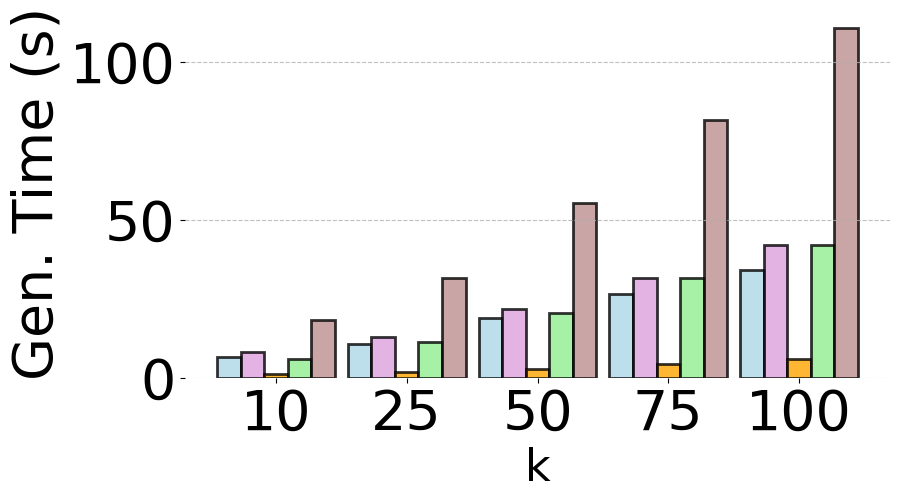

Saved figure to ./../../experiments/plots/darth_journal/calibration_gathering_time_all_datasets.pdf


In [37]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M", "DEEP100M", "GLOVE100", "GIST1M", "T2I100M"]

plt.rcParams.update({'font.size': 40})
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(all_k_values))
width = 0.18
for idx, ds_name in enumerate(all_datasets):
    vals = [
        darth_plus_gathering_calibration_times.get(ds_name, {}).get(f"k{k}", np.nan)
        for k in all_k_values
    ]
    
    ax.bar(
        x + (idx - len(all_datasets) / 2 + 0.5) * width,
        vals,
        width=width,
        label=ds_name,
        alpha=0.8,
        linewidth=2,
        edgecolor="black",
        color=DATASET_PARAMS[ds_name]["color"]
    )

ax.set_xticks(x)
ax.set_xticklabels(all_k_values)
ax.set_xlabel("k", fontsize=32)
ax.set_ylabel("Gen. Time (s)", fontsize=40)
ax.grid(alpha=0.8, axis='y', linestyle='--')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

savepath = f"./../../experiments/plots/darth_journal/calibration_gathering_time_all_datasets.pdf"
fig.savefig(savepath, bbox_inches='tight')
print(f"Saved figure to {savepath}")

In [38]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M", "GLOVE100", "DEEP100M", "GIST1M", "T2I100M"]
expected_coverages = [0.8, 0.9, 0.95]
feature_classes = ["darth_and_query_dims"]
n_estimators = 100

quantile_pairs = []

print("Total quantile pairs to evaluate:", len(quantile_pairs), ": ", quantile_pairs)
calibration_times = {}
for ds_name in all_datasets:
    calibration_times[ds_name] = {}
    ds_results = {}
    for k in all_k_values:
        calib_time_start = time.time()
        ds_results[k] = {}
        M = DATASET_PARAMS[ds_name]["M"]
        efC = DATASET_PARAMS[ds_name]["efC"]
        efS = DATASET_PARAMS[ds_name]["efS"]

        calibration_df = dd_load_as_pd(get_calibration_dataset_name(M, efC, efS, 1000, ds_name, k), columns_to_load=COLUMNS_TO_LOAD)
        calibration_y = calibration_df["r"]
        for feature_class_name in feature_classes:
            ds_results[k][feature_class_name] = {}
            calibration_x = calibration_df[FEATURE_CLASSES[feature_class_name]]

            regression_model = lgb.Booster(
                model_file=os.path.join(
                    DARTH_PLUS_MODEL_DIRECTORY,
                    f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_darth_and_query_dims_regr_nest{n_estimators}.txt"
                )
            )
            ds_results[k][feature_class_name]["normal_regression"] = {}
            
            calibration_preds = regression_model.predict(calibration_x)
            lower_nonconformity_scores = calibration_preds - calibration_y
            upper_nonconformity_scores = calibration_y - calibration_preds
            lower_nonconformity_scores = np.maximum(lower_nonconformity_scores, 0.0)
            upper_nonconformity_scores = np.maximum(upper_nonconformity_scores, 0.0)
            for expected_coverage in expected_coverages:
                #quantile_level = expected_coverage
                alpha = 1.0 - expected_coverage
                n = len(calibration_y)
                quantile_level = np.ceil((n + 1) * (1 - alpha)) / n
                quantile_level = min(quantile_level, 1.0)             
                q_hat_lower = np.quantile(lower_nonconformity_scores, quantile_level, method="higher")
                q_hat_upper = np.quantile(upper_nonconformity_scores, quantile_level, method="higher")
                
                ds_results[k][feature_class_name]["normal_regression"][expected_coverage] = {
                    "q_hat_lower": q_hat_lower,
                    "q_hat_upper": q_hat_upper
                }
            
            for quantile_pair in quantile_pairs:
                ds_results[k][feature_class_name][str(quantile_pair)] = {}
                low_quantile, up_quantile = quantile_pair
                low_model_path = os.path.join(DARTH_PLUS_MODEL_DIRECTORY, f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_{feature_class_name}_quant{low_quantile}_nest{n_estimators}.txt")
                mdl_low = lgb.Booster(model_file=low_model_path)

                up_model_path = os.path.join(DARTH_PLUS_MODEL_DIRECTORY, f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_{feature_class_name}_quant{up_quantile}_nest{n_estimators}.txt")
                mdl_up = lgb.Booster(model_file=up_model_path)

                qhat_low_calib = mdl_low.predict(calibration_x)
                qhat_up_calib = mdl_up.predict(calibration_x)

                qhat_low_calib = np.clip(qhat_low_calib, 0.0, 1.0)
                qhat_up_calib = np.clip(qhat_up_calib, 0.0, 1.0)

                # Calculate separate nonconformity scores for lower and upper predictions
                lower_nonconformity_scores = qhat_low_calib - calibration_y  # How much lower prediction exceeds truth
                upper_nonconformity_scores = calibration_y - qhat_up_calib   # How much truth exceeds upper prediction
                
                # Clip scores to non-negative (we only care about violations)
                lower_nonconformity_scores = np.maximum(lower_nonconformity_scores, 0.0)
                upper_nonconformity_scores = np.maximum(upper_nonconformity_scores, 0.0)
                
                n_cal = len(calibration_y)

                for expected_coverage in expected_coverages:
                    alpha = 1 - expected_coverage
                    k_ = int(np.ceil((1 - alpha) * (n_cal + 1))) - 1
                    k_ = np.clip(k_, 0, n_cal - 1)
                    
                    # Calculate separate q_hat for lower and upper predictions
                    q_hat_lower = np.sort(lower_nonconformity_scores)[k_]
                    q_hat_upper = np.sort(upper_nonconformity_scores)[k_]
                    
                    ds_results[k][feature_class_name][str(quantile_pair)][expected_coverage] = {
                        "q_hat_lower": q_hat_lower,
                        "q_hat_upper": q_hat_upper
                    }
        
        calib_time = time.time() - calib_time_start
        print(f"Calibration for {ds_name} k={k} took {calib_time:.2f} seconds")
        calibration_times[ds_name][k] = calib_time
    
    json_path = os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_conformal_{ds_name}.json")
    json.dump(ds_results, open(json_path, "w"), indent=4)
    print(f"Saved results to {json_path}")

Total quantile pairs to evaluate: 0 :  []
Calibration for SIFT100M k=10 took 2.35 seconds
Calibration for SIFT100M k=25 took 4.30 seconds
Calibration for SIFT100M k=50 took 5.20 seconds
Calibration for SIFT100M k=75 took 6.27 seconds
Calibration for SIFT100M k=100 took 6.83 seconds
Saved results to ./../../experiments/darth_plus_jsons/darth_plus_conformal_SIFT100M.json
Calibration for GLOVE100 k=10 took 0.81 seconds
Calibration for GLOVE100 k=25 took 0.94 seconds
Calibration for GLOVE100 k=50 took 1.12 seconds
Calibration for GLOVE100 k=75 took 1.59 seconds
Calibration for GLOVE100 k=100 took 1.92 seconds
Saved results to ./../../experiments/darth_plus_jsons/darth_plus_conformal_GLOVE100.json
Calibration for DEEP100M k=10 took 3.22 seconds
Calibration for DEEP100M k=25 took 4.88 seconds
Calibration for DEEP100M k=50 took 8.45 seconds
Calibration for DEEP100M k=75 took 9.65 seconds
Calibration for DEEP100M k=100 took 10.55 seconds
Saved results to ./../../experiments/darth_plus_jsons/da

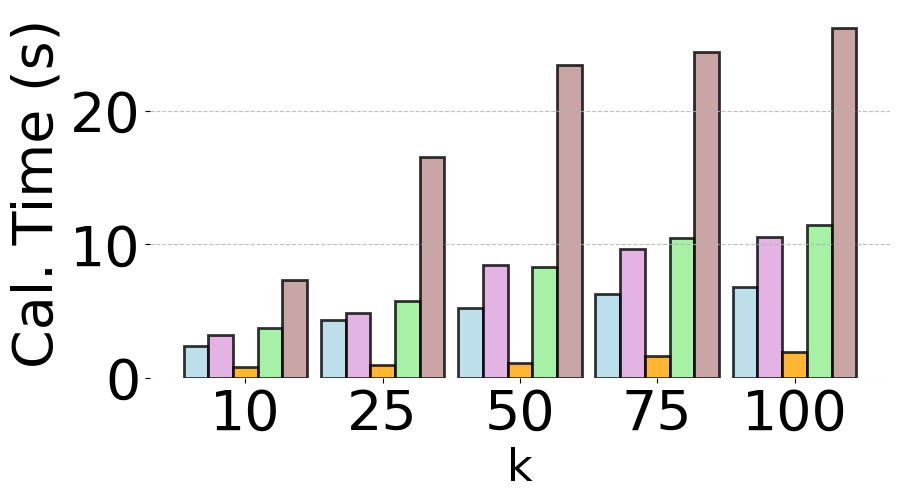

Saved figure to ./../../experiments/plots/darth_journal/calibration_time_all_datasets.pdf


In [40]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M", "DEEP100M", "GLOVE100", "GIST1M", "T2I100M"]

plt.rcParams.update({'font.size': 40})
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(all_k_values))
width = 0.18
for idx, ds_name in enumerate(all_datasets):
    vals = [
        calibration_times[ds_name][k]
        for k in all_k_values
    ]
    
    ax.bar(
        x + (idx - len(all_datasets) / 2 + 0.5) * width,
        vals,
        width=width,
        label=ds_name,
        alpha=0.8,
        linewidth=2,
        edgecolor="black",
        color=DATASET_PARAMS[ds_name]["color"]
    )

ax.set_xticks(x)
ax.set_xticklabels(all_k_values)
ax.set_xlabel("k", fontsize=32)
ax.set_ylabel("Cal. Time (s)", fontsize=40)
ax.grid(alpha=0.8, axis='y', linestyle='--')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

savepath = f"./../../experiments/plots/darth_journal/calibration_time_all_datasets.pdf"
fig.savefig(savepath, bbox_inches='tight')
print(f"Saved figure to {savepath}")

### Quantile model training times

In [ ]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M", "GLOVE100", "DEEP100M", "GIST1M", "T2I100M"]
feature_class = "darth_and_query_dims"
n_estimators = 100

low_quantiles = [0.05, 0.1, 0.2]

results = {}
for ds_name in all_datasets:
    results[ds_name] = {}
    M = DATASET_PARAMS[ds_name]["M"]
    efC = DATASET_PARAMS[ds_name]["efC"]
    efS = DATASET_PARAMS[ds_name]["efS"]
    json_path = os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"hnsw_{ds_name}_M{M}_efC{efC}_efS{efS}_training_results.json")
    with open(json_path, "r") as f:
        q_results = json.load(f)
    for k in all_k_values:
        results[ds_name][k] = {}
        for quantile in low_quantiles:
            quantile_data = q_results["training_results"][f"k{k}"][feature_class][f"nest{n_estimators}"][f"quant{quantile}"]
            train_time = quantile_data["train_time"]
            results[ds_name][k][quantile] = {
                "train_time": train_time
            }
        
        

In [ ]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M", "DEEP100M", "GLOVE100", "GIST1M", "T2I100M"]
low_quantile = 0.1
measure = "train_time"

plt.rcParams.update({'font.size': 40})
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(all_k_values))
width = 0.16
for idx, ds_name in enumerate(all_datasets):
    vals = [
        results[ds_name][k][low_quantile][measure]
        for k in all_k_values
    ]
    
    ax.bar(
        x + (idx - len(all_datasets) / 2 + 0.5) * width,
        vals,
        width=width,
        label=ds_name,
        alpha=0.8,
        linewidth=2,
        edgecolor="black",
        color=DATASET_PARAMS[ds_name]["color"]
    )

ax.set_xticks(x)
ax.set_xticklabels(all_k_values)
ax.set_xlabel("k")
ax.set_ylabel("Train Time (s)", fontsize=40)
ax.grid(alpha=0.8, axis='y', linestyle='--')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

savepath = f"./../../experiments/plots/darth_journal/quantile_{low_quantile}_{measure}_all_datasets.pdf"
fig.savefig(savepath, bbox_inches='tight')
print(f"Saved figure to {savepath}")

### Model Validation

In [ ]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M", "GLOVE100", "DEEP100M", "GIST1M", "T2I100M"]
expected_coverages = [0.8, 0.9]
feature_classes = ["darth_and_query_dims"]
n_estimators = 100

quantile_pairs = [(0.10, 0.90), (0.05, 0.95)]

results = {}
for ds_name in all_datasets:
    results[ds_name] = {}
    conformal_qhats = {}
    with open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_conformal_{ds_name}.json"), "r") as f:
        conformal_qhats = json.load(f)        
        
    for k in all_k_values:
        results[ds_name][k] = {}
        M = DATASET_PARAMS[ds_name]["M"]
        efC = DATASET_PARAMS[ds_name]["efC"]
        efS = DATASET_PARAMS[ds_name]["efS"]

        validation_df = dd_load_as_pd(get_validation_dataset_name(M, efC, efS, 1000, ds_name, k), columns_to_load=COLUMNS_TO_LOAD)
        validation_y = validation_df["r"]
        validation_X = validation_df[FEATURE_CLASSES[feature_class_name]]
        
        regression_model = lgb.Booster(
            model_file=os.path.join(
                DARTH_PLUS_MODEL_DIRECTORY,
                f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_darth_and_query_dims_regr_nest{n_estimators}.txt"
            )
        )
        results[ds_name][k]["normal_regression"] = {}
        
        validation_preds = regression_model.predict(validation_X)
        for expected_coverage in expected_coverages:
            q_hats = conformal_qhats[f"{k}"][feature_class_name]["normal_regression"][f"{expected_coverage}"]
            validation_preds_lower = validation_preds - q_hats["q_hat_lower"]
            validation_preds_upper = validation_preds + q_hats["q_hat_upper"]
            
            validation_preds_lower = np.clip(validation_preds_lower, 0.0, 1.0)
            validation_preds_upper = np.clip(validation_preds_upper, 0.0, 1.0)
            
            coverage = np.mean((validation_y >= validation_preds_lower) & (validation_y <= validation_preds_upper))
            avg_len = np.mean(validation_preds_upper - validation_preds_lower)
            print(f"{ds_name} k={k} expected_coverage={expected_coverage}: coverage={coverage:.4f}, avg_length={avg_len:.4f}")
            
            results[ds_name][k]["normal_regression"][f"{expected_coverage}"] = {
                "coverage": coverage,
                "avg_length": avg_len,
            }
        
        for quantile_pair in quantile_pairs:
            results[ds_name][k][str(quantile_pair)] = {}
            low_quantile, up_quantile = quantile_pair
            low_model_path = os.path.join(DARTH_PLUS_MODEL_DIRECTORY, f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_{feature_class_name}_quant{low_quantile}_nest{n_estimators}.txt")
            mdl_low = lgb.Booster(model_file=low_model_path)

            up_model_path = os.path.join(DARTH_PLUS_MODEL_DIRECTORY, f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_{feature_class_name}_quant{up_quantile}_nest{n_estimators}.txt")
            mdl_up = lgb.Booster(model_file=up_model_path)

            y_low = mdl_low.predict(validation_X)
            y_high = mdl_up.predict(validation_X)

            y_low = np.clip(y_low, 0.0, 1.0)
            y_high = np.clip(y_high, 0.0, 1.0)
            
            expected_coverage = up_quantile - low_quantile
            for exp_cov in expected_coverages:
                if abs(expected_coverage - exp_cov) < 0.00001:
                    expected_coverage = exp_cov
                    break
            
            coverage = np.mean((validation_y >= y_low) & (validation_y <= y_high))
            avg_len = np.mean(y_high - y_low)
            print(f"{ds_name} k={k} quantile_pair={quantile_pair} expected_coverage={expected_coverage}: coverage={coverage:.4f}, avg_length={avg_len:.4f}")
                
            results[ds_name][k][str(quantile_pair)][f"{expected_coverage}"] = {
                "coverage": coverage,
                "avg_length": avg_len,
            }

            #for expected_coverage in expected_coverages:
            #    q_hats = conformal_qhats[f"{k}"][feature_class_name][str(quantile_pair)][f"{expected_coverage}"]
            #    y_low_qhat = y_low - q_hats["q_hat_lower"]
            #    y_high_qhat = y_high + q_hats["q_hat_upper"]
            #    
            #    y_low_qhat = np.clip(y_low_qhat, 0.0, 1.0)
            #    y_high_qhat = np.clip(y_high_qhat, 0.0, 1.0)
            #    
            #    coverage = np.mean((validation_y >= y_low_qhat) & (validation_y <= y_high_qhat))
            #    avg_len = np.mean(y_high_qhat - y_low_qhat)
            #    print(f"{ds_name} k={k} quantile_pair={quantile_pair} expected_coverage={expected_coverage}: coverage={coverage:.4f}, avg_length={avg_len:.4f}")
            #    
            #    results[ds_name][k][str(quantile_pair)][f"{expected_coverage}"] = {
            #        "coverage": coverage,
            #        "avg_length": avg_len,
            #    }
            


In [ ]:
all_k_values = [10, 50, 100]
all_datasets = ["GLOVE100"]
expected_coverages = [0.7, 0.8, 0.9, 0.95]
feature_classes = ["darth_and_query_dims"]
n_estimators = 100

low_trained_quantiles = [0.05, 0.10, 0.20, 0.30]
up_trained_quantiles = [0.70, 0.80, 0.90, 0.95]
quantile_pairs = [(low, up) for low in low_trained_quantiles for up in up_trained_quantiles]

models_to_test = ["normal_regression"] + [str(qp) for qp in quantile_pairs]
measures = ["coverage", "avg_length"]

# Track wins for each model
model_wins = {model: 0 for model in models_to_test}

# Calculate and print average metrics for each model across all k_values
print("Average metrics across all k_values:")
print("=" * 80)
for ds_name in all_datasets:
    print(f"\nDataset: {ds_name}")
    #for alpha in alphas:
    for expected_coverage in expected_coverages:
        print(f"\n  expected_coverage={expected_coverage}:")
        
        # Track valid models and their metrics
        valid_models = {}
        
        for model in models_to_test:
            avg_coverage = np.mean([results[ds_name][k][str(model)][f"{expected_coverage}"]["coverage"] for k in all_k_values])
            avg_length = np.mean([results[ds_name][k][str(model)][f"{expected_coverage}"]["avg_length"] for k in all_k_values])
            print(f"    {model:20s}: avg_coverage={avg_coverage:.4f}, avg_length={avg_length:.4f}")
            
            # Only consider models that meet the coverage requirement
            if avg_coverage >= expected_coverage - 0.05:
                valid_models[model] = avg_length
        
        # Find and print the best model (smallest avg_length)
        if valid_models:
            best_model = min(valid_models, key=valid_models.get)
            best_length = valid_models[best_model]
            model_wins[best_model] += 1
            print(f"\n    → Best model (smallest avg_length with coverage >= {expected_coverage}): {best_model} with avg_length={best_length:.4f}")
        else:
            print(f"\n    → No models meet the coverage requirement of {expected_coverage}")

print("=" * 80)

# Print overall winner
print("\n" + "=" * 80)
print("OVERALL WINNER ACROSS ALL DATASETS AND ALPHAS:")
print("=" * 80)
for model, wins in sorted(model_wins.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model:20s}: {wins} wins")

overall_best_model = max(model_wins, key=model_wins.get)
overall_best_wins = model_wins[overall_best_model]
print(f"\n→ Overall best model: {overall_best_model} with {overall_best_wins} wins")
print("=" * 80)

# Print average stats for the best model
print("\n" + "=" * 80)
print(f"AVERAGE STATISTICS FOR BEST MODEL: {overall_best_model}")
print("=" * 80)
for ds_name in all_datasets:
    print(f"\nDataset: {ds_name}")
    for expected_coverage in expected_coverages:
        avg_coverage = np.mean([results[ds_name][k][str(overall_best_model)][f"{expected_coverage}"]["coverage"] for k in all_k_values])
        avg_length = np.mean([results[ds_name][k][str(overall_best_model)][f"{expected_coverage}"]["avg_length"] for k in all_k_values])
        print(f"  expected_coverage={expected_coverage:.2f}: avg_coverage={avg_coverage:.4f}, avg_length={avg_length:.4f}")

# Overall average across all datasets and alphas
print("\n" + "-" * 80)
print("OVERALL AVERAGE ACROSS ALL DATASETS AND ALPHAS:")
all_coverages = []
all_lengths = []
for ds_name in all_datasets:
    for expected_coverage in expected_coverages:
        for k in all_k_values:
            all_coverages.append(results[ds_name][k][str(overall_best_model)][f"{expected_coverage}"]["coverage"])
            all_lengths.append(results[ds_name][k][str(overall_best_model)][f"{expected_coverage}"]["avg_length"])

print(f"  Average coverage: {np.mean(all_coverages):.4f} (±{np.std(all_coverages):.4f})")
print(f"  Average length: {np.mean(all_lengths):.4f} (±{np.std(all_lengths):.4f})")
print("=" * 80)

### Calculate the dataset params to run the end-to-end experiments.

#### Regression without conformal parameters

In [ ]:
all_datasets = ["GLOVE100", "SIFT100M", "DEEP100M", "GIST1M", "T2I100M"]
all_k_values = [10, 25, 50, 75, 100]
target_recalls = [0.80, 0.85, 0.90, 0.95, 0.99]

for ds_name in all_datasets:
    conformal_qhats = {}
    with open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_conformal_{ds_name}.json"), "r") as f:
        conformal_qhats = json.load(f) 
    pi_params = {}
    for k in all_k_values:
        M = DATASET_PARAMS[ds_name]["M"]
        efC = DATASET_PARAMS[ds_name]["efC"]
        efS = DATASET_PARAMS[ds_name]["efS"]
        data_df = dd_load_as_pd(get_dataset_name_darthplus(M, efC, efS, 10000, ds_name, k), COLUMNS_TO_LOAD)   
        pi_params[k] = dp_find_pi_params(data_df, target_recalls=target_recalls)
    
    for k in all_k_values:
        print(f"{ds_name}_tuples_k{k}=(")
        for rt in target_recalls:
            ipi = pi_params[k][rt]["ipi"]
            mpi = pi_params[k][rt]["mpi"]
            print(f"    \"{rt:.2f} {ipi} {mpi}\"")
        print(")")  
    print()

    json.dump(pi_params, open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_pi_params_{ds_name}.json"), "w"), indent=4)
    


#### Regression with conformal parameters

In [ ]:

all_datasets = ["GLOVE100", "SIFT100M", "DEEP100M", "GIST1M", "T2I100M"]
all_k_values = [10, 25, 50, 75, 100]

expected_coverages = [0.9, 0.95]
target_recalls = [0.80, 0.85, 0.90, 0.95, 0.99]

mode_quantile_or_normal = "normal_regression" # or (0.20, 0.80), (0.10, 0.90), etc.

for ds_name in all_datasets:
    conformal_qhats = {}
    with open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_conformal_{ds_name}.json"), "r") as f:
        conformal_qhats = json.load(f) 
    pi_params = {}
    for k in all_k_values:
        M = DATASET_PARAMS[ds_name]["M"]
        efC = DATASET_PARAMS[ds_name]["efC"]
        efS = DATASET_PARAMS[ds_name]["efS"]
        data_df = dd_load_as_pd(get_dataset_name_darthplus(M, efC, efS, 10000, ds_name, k), COLUMNS_TO_LOAD)

        y = data_df["r"]
        #print(data_df.shape)
        
        pi_params[k] = dp_find_pi_params(data_df, target_recalls=target_recalls)
    
    for k in all_k_values:
        print(f"{ds_name}_tuples_k{k}=(")
        for expected_coverage in expected_coverages:
            for rt in target_recalls:
                ipi = pi_params[k][rt]["ipi"]
                mpi = pi_params[k][rt]["mpi"]
                q_hat_high = conformal_qhats[f"{k}"]["darth_and_query_dims"][str(mode_quantile_or_normal)][f"{expected_coverage}"]["q_hat_upper"]
                q_hat_low = conformal_qhats[f"{k}"]["darth_and_query_dims"][str(mode_quantile_or_normal)][f"{expected_coverage}"]["q_hat_lower"]
                print(f"    \"{rt:.2f} {ipi} {mpi} {expected_coverage:.2f} {q_hat_high:.3f} {q_hat_low:.3f}\"")
        print(")")  
    print()  
    

## HNSW Comparisons on testing 

### Model prediction results on full resolution for testing/validation data

In [41]:
query_type = "testing"
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M", "DEEP100M", "GLOVE100", "GIST1M", "T2I100M"]
expected_coverages = [0.8, 0.9, 0.95]
feature_class_name = "darth_and_query_dims"
n_estimators = 100
low_quantiles = [0.05, 0.10, 0.20]

results = {}
for ds_name in all_datasets:
    results[ds_name] = {}
    with open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_conformal_{ds_name}.json"), "r") as f:
        conformal_qhats = json.load(f)

    for k in all_k_values:
        results[ds_name][k] = {}
        M = DATASET_PARAMS[ds_name]["M"]
        efC = DATASET_PARAMS[ds_name]["efC"]
        efS = DATASET_PARAMS[ds_name]["efS"]

        if query_type == "testing":
            dataset_name = get_testing_dataset_name(M, efC, efS, 1000, ds_name, k)
        else:
            dataset_name = get_validation_dataset_name(M, efC, efS, 1000, ds_name, k)

        query_df = dd_load_as_pd(dataset_name, columns_to_load=COLUMNS_TO_LOAD)
        query_y = query_df["r"]
        query_X = query_df[FEATURE_CLASSES[feature_class_name]]

        regression_model = lgb.Booster(
            model_file=os.path.join(
                DARTH_PLUS_MODEL_DIRECTORY,
                f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_darth_and_query_dims_regr_nest{n_estimators}.txt"
            )
        )

        query_preds = regression_model.predict(query_X)

        for expected_coverage in expected_coverages:
            q_hats = conformal_qhats[f"{k}"][feature_class_name]["normal_regression"][f"{expected_coverage}"]

            query_preds_lower = query_preds - q_hats["q_hat_lower"]
            query_preds_upper = query_preds + q_hats["q_hat_upper"]

            query_preds_lower = np.clip(query_preds_lower, 0.0, 1.0)
            query_preds_upper = np.clip(query_preds_upper, 0.0, 1.0)

            coverage = np.mean((query_y >= query_preds_lower) & (query_y <= query_preds_upper))
            miss_ratio_lower = np.mean(query_y < query_preds_lower)
            miss_ratio_upper = np.mean(query_y > query_preds_upper)
            avg_len = np.mean(query_preds_upper - query_preds_lower)

            print(f"{ds_name} k={k} expected_coverage={expected_coverage}: coverage={coverage:.4f}, avg_length={avg_len:.4f}, miss_ratio_lower={miss_ratio_lower:.4f}, miss_ratio_upper={miss_ratio_upper:.4f}")

            results[ds_name][k][f"darth+_classic_cov_{expected_coverage}"] = {
                "coverage": coverage,
                "avg_length": avg_len,
                "miss_ratio_lower": miss_ratio_lower,
                "miss_ratio_upper": miss_ratio_upper,
            }

        for low_quantile in low_quantiles:
            mdl_low = lgb.Booster(
                model_file=os.path.join(
                    DARTH_PLUS_MODEL_DIRECTORY,
                    f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_{feature_class_name}_quant{low_quantile}_nest{n_estimators}.txt"
                )
            )

            query_y_low = np.clip(mdl_low.predict(query_X), 0.0, 1.0)
            miss_ratio_lower = np.mean(query_y < query_y_low)


            print(f"{ds_name} k={k} low_quantile={low_quantile}: miss_ratio_lower={miss_ratio_lower:.4f}")

            results[ds_name][k][f"darth+_quant_lq{low_quantile}"] = {
                "miss_ratio_lower": miss_ratio_lower,
            }


SIFT100M k=10 expected_coverage=0.8: coverage=0.7913, avg_length=0.1141, miss_ratio_lower=0.0667, miss_ratio_upper=0.1420
SIFT100M k=10 expected_coverage=0.9: coverage=0.9173, avg_length=0.1811, miss_ratio_lower=0.0411, miss_ratio_upper=0.0417
SIFT100M k=10 expected_coverage=0.95: coverage=0.9614, avg_length=0.2549, miss_ratio_lower=0.0238, miss_ratio_upper=0.0148
SIFT100M k=10 low_quantile=0.05: miss_ratio_lower=0.0228
SIFT100M k=10 low_quantile=0.1: miss_ratio_lower=0.0391
SIFT100M k=10 low_quantile=0.2: miss_ratio_lower=0.0542
SIFT100M k=25 expected_coverage=0.8: coverage=0.7664, avg_length=0.0668, miss_ratio_lower=0.1137, miss_ratio_upper=0.1199
SIFT100M k=25 expected_coverage=0.9: coverage=0.8899, avg_length=0.1144, miss_ratio_lower=0.0665, miss_ratio_upper=0.0436
SIFT100M k=25 expected_coverage=0.95: coverage=0.9408, avg_length=0.1616, miss_ratio_lower=0.0408, miss_ratio_upper=0.0184
SIFT100M k=25 low_quantile=0.05: miss_ratio_lower=0.0388
SIFT100M k=25 low_quantile=0.1: miss_rat

In [ ]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["SIFT100M", "DEEP100M", "GLOVE100", "GIST1M", "T2I100M"]
expected_coverages = [0.9, 0.95]
models_to_test = [f"darth+_classic_cov_{exp_cov}" for exp_cov in expected_coverages]
measures = ["avg_length", "coverage"]
measure_labels = {
    "coverage": "Actual Cov.",
    "avg_length": "Av. Ran. Len.",
}


for measure in measures:
    for exp_cov_idx, exp_cov in enumerate(expected_coverages):
        plt.rcParams.update({'font.size': 40})
        fig, ax = plt.subplots(figsize=(10, 6))

        x = np.arange(len(all_k_values))
        width = 0.16
        for idx, ds_name in enumerate(all_datasets):
            vals = [
                    results[ds_name][k][models_to_test[exp_cov_idx]][measure]
                    for k in all_k_values
            ]
                
            ax.bar(
                    x + (idx - len(all_datasets) / 2 + 0.5) * width,
                    vals,
                    width=width,
                    label=ds_name,
                    alpha=0.8,
                    linewidth=2,
                    edgecolor="black",
                    color=DATASET_PARAMS[ds_name]["color"]
            )
        
        if measure == "coverage":
            #ax.set_yticks([0.7, 0.8, 0.85, 0.9, 0.95])
            #ax.set_ylim(0.7, 0.95)
            ax.axhline(y=exp_cov, color='red', linestyle='--', alpha=0.7, linewidth=2)


        ax.set_xticks(x)
        ax.set_xticklabels(all_k_values)
        ax.set_xlabel("k")
        ax.set_ylabel(measure_labels[measure])
        #ax.set_title(f"Expected Coverage: {exp_cov}")
        ax.grid(alpha=0.8, axis='y', linestyle='--')
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        #ax.legend(loc='lower right', fontsize=30)

        plt.tight_layout()
        plt.show()
        
        savepath = f"./../../experiments/plots/darth_journal/conformal_{measure}_{exp_cov}.pdf"
        fig.savefig(savepath, bbox_inches='tight')
        print(f"Saved figure to {savepath}")

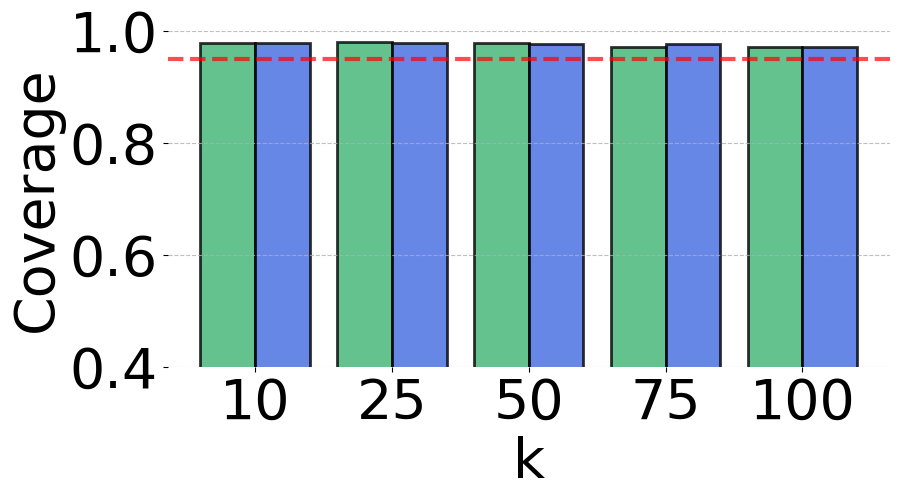

Saved figure to ./../../experiments/plots/darth_journal/guar_comparison_GLOVE100_miss_ratio_lower_0.95.pdf


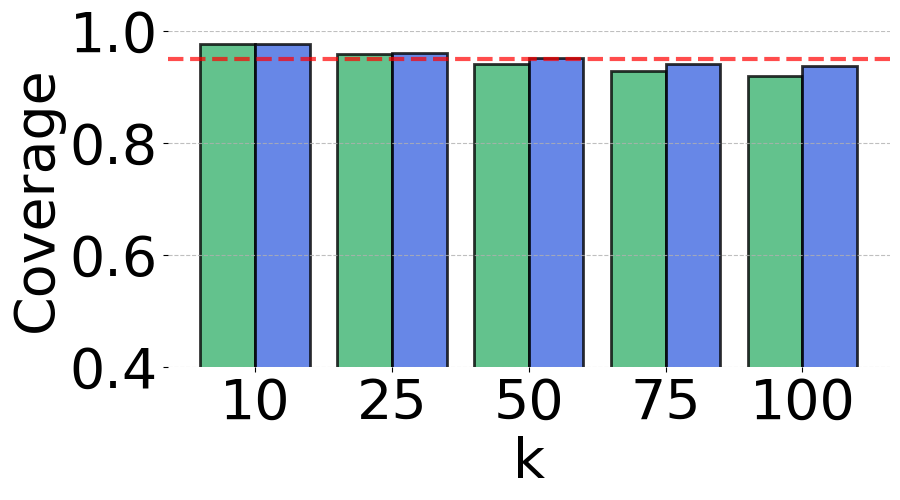

Saved figure to ./../../experiments/plots/darth_journal/guar_comparison_SIFT100M_miss_ratio_lower_0.95.pdf


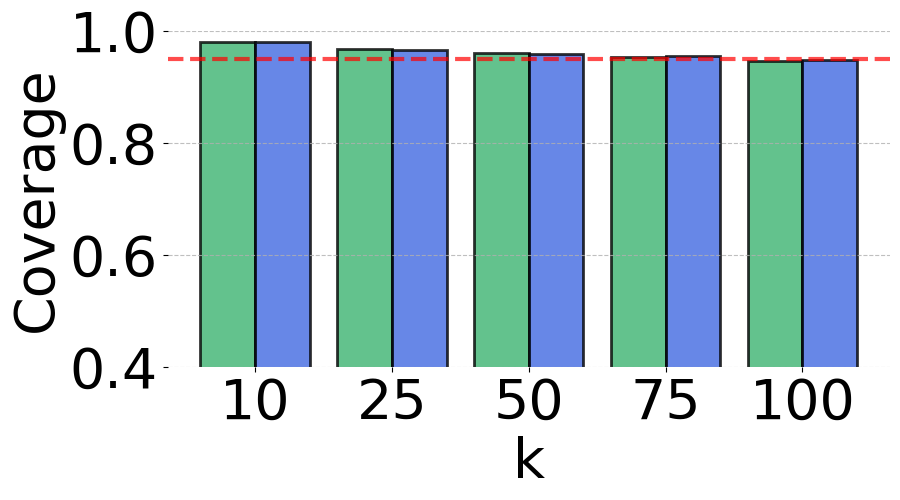

Saved figure to ./../../experiments/plots/darth_journal/guar_comparison_DEEP100M_miss_ratio_lower_0.95.pdf


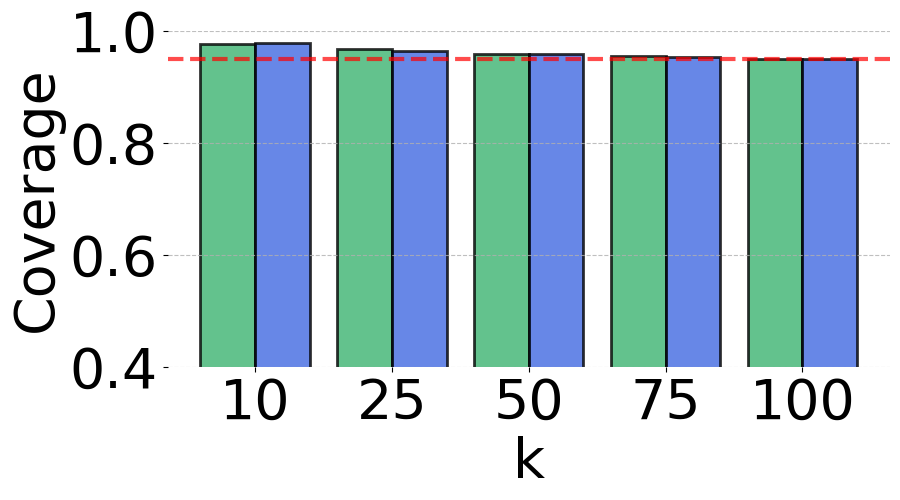

Saved figure to ./../../experiments/plots/darth_journal/guar_comparison_GIST1M_miss_ratio_lower_0.95.pdf


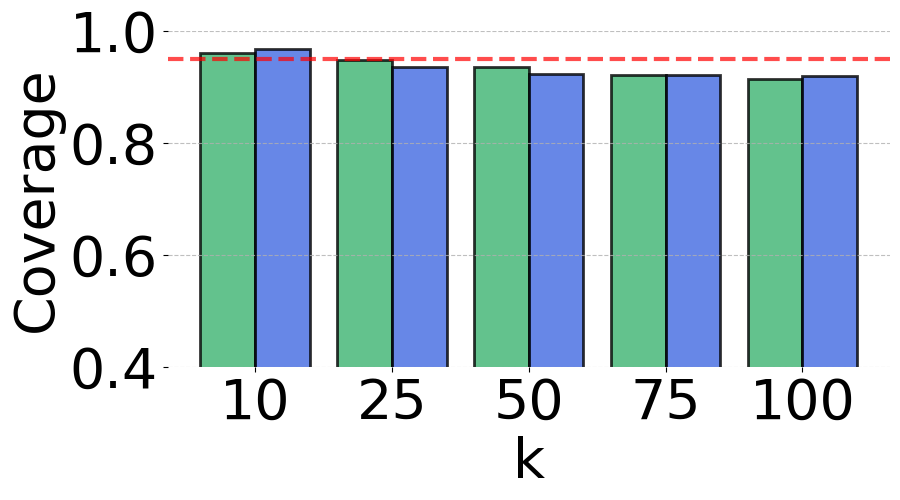

Saved figure to ./../../experiments/plots/darth_journal/guar_comparison_T2I100M_miss_ratio_lower_0.95.pdf


<Figure size 600x80 with 0 Axes>

In [54]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["GLOVE100", "SIFT100M", "DEEP100M", "GIST1M", "T2I100M"]
expected_coverage = 0.95
low_quantile = 0.05

models_to_test = [f"darth+_classic_cov_{expected_coverage}"] + [f"darth+_quant_lq{low_quantile}"]
measures = ["miss_ratio_lower"]

measure_labels = {
    "miss_ratio_lower": "LB Miss Ratio",
    "miss_ratio_upper": "Upper Bound Miss Ratio",
}

generate_unified_plot = False 

for measure in measures:
    if generate_unified_plot:
        plt.rcParams.update({'font.size': 11})
        # -----------------------------
        # Unified figure
        # -----------------------------
        n_ds = len(all_datasets)
        fig, axs = plt.subplots(nrows=1, ncols=n_ds, figsize=(3 * max(1, n_ds), 3))
        if n_ds == 1:
            axs = [axs]

        legend_handles = None
        legend_labels = None

        for ds_idx, ds_name in enumerate(all_datasets):
            ax = axs[ds_idx]
            x = np.arange(len(all_k_values))
            x_values = models_to_test
            n_x_values = len(x_values)
            width = 0.2

            for i, model in enumerate(x_values):
                vals = [
                    results[ds_name][k][str(model)][measure]
                    for k in all_k_values
                ]
                ax.bar(
                    x + i * width,
                    vals,
                    width=width,
                    label=algorithm_conf[model]["label"],
                    color=algorithm_conf[model]["color"],
                )

            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

            ax.set_xticks(x + (n_x_values - 1) * width / 2)
            ax.set_xticklabels(all_k_values)
            ax.set_xlabel("k")
            ax.set_ylabel(measure_labels[measure])
            ax.set_title(ds_name)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncols=len(models_to_test),
            frameon=False,
            bbox_to_anchor=(0.5, 1.05),
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    else:
        # ---------------------------------
        # Separate figure per dataset
        # + standalone legend figure
        # ---------------------------------
        legend_handles = None
        legend_labels = None

        for ds_name in all_datasets:
            fig, ax = plt.subplots(figsize=(10, 6))
            plt.rcParams.update({'font.size': 40})

            x = np.arange(len(all_k_values))
            x_values = models_to_test
            n_x_values = len(x_values)
            width = 0.4

            for i, model in enumerate(x_values):
                vals = [
                    1 - results[ds_name][k][str(model)][measure]
                    for k in all_k_values
                ]
                ax.bar(
                    x + i * width,
                    vals,
                    width=width,
                    label=algorithm_conf[model]["label"],
                    color=algorithm_conf[model]["color"],
                    alpha=0.8,
                    linewidth=2,
                    edgecolor="black",
                )

            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()
                
            # add a line to the expected ratio (1 - expected coverage):
            if measure == "miss_ratio_lower":
                expected_miss_ratio = 1.0 - expected_coverage
                ax.axhline(y=expected_coverage, color='red', linestyle='--', alpha=0.7, linewidth=3)

            ax.set_xticks(x + (n_x_values - 1) * width / 2)
            ax.set_xticklabels(all_k_values)
            ax.set_xlabel("k")
            #ax.set_ylabel(measure_labels[measure])
            ax.set_ylabel("Coverage")
            ax.grid(alpha=0.8, axis='y', linestyle='--')
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_ylim(0.4, 1.0)

            plt.tight_layout()
            plt.show()
            
            savepath = f"./../../experiments/plots/darth_journal/guar_comparison_{ds_name}_{measure}_{expected_coverage}.pdf"
            fig.savefig(savepath, bbox_inches='tight')
            print(f"Saved figure to {savepath}")

        # -----------------------------
        # Standalone legend figure
        # -----------------------------
        fig_legend = plt.figure(figsize=(3 * len(models_to_test), 0.8))
        fig_legend.legend(
            legend_handles,
            legend_labels,
            loc="center",
            ncols=len(models_to_test),
            frameon=False,
        )
        fig_legend.tight_layout()
        plt.show()


### Calculate the results and keep them in-memory

In [3]:
all_datasets = ["SIFT100M", "GLOVE100", "DEEP100M", "GIST1M", "T2I100M"]
all_k_values = [10, 25, 50, 75, 100]
recall_targets = [0.80, 0.85, 0.9, 0.95, 0.99]
measures_to_cmp = ["avgRecall", "RQUT", "RDE", "QPS", "Worst1perc", "Dist", "avgError"]

expected_coverages = [0.9]#[0.9] #[0.8, 0.9]
low_quantiles = [0.1]
s = 1000

models_to_test = ["baseline", "rem", "laet", "darth", "darth+_classic", "no_early_stop"]
for exp_cov in expected_coverages:
    models_to_test += [f"darth+_classic_cov_{exp_cov}"]
        
for lq in low_quantiles:
    models_to_test += [f"darth+_quant_lq{lq}"]

darth_json_pi_data = json.load(open("../../experiments/generated_json/final_heuristic_adaptive_recommendations_params_ipidiv2_mpidiv10.json"))
rem_data = json.load(open(f"{DARTH_JSON_DIRECTORY}/classic_hnsw_tuning_results_memoryFalse_validationSize1000.json"))

results = {}
for ds_name in all_datasets:
    if ds_name == "T2I100M":
        recall_targets = [0.80, 0.85, 0.9, 0.95]
    else:
        recall_targets = [0.80, 0.85, 0.9, 0.95, 0.99]
    
    darth_plus_json_pi_data = json.load(open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_pi_params_{ds_name}.json")))
    
    results[ds_name] = {}
    M = DATASET_PARAMS[ds_name]["M"]
    efC = DATASET_PARAMS[ds_name]["efC"]
    efS = DATASET_PARAMS[ds_name]["efS"]

    for k in all_k_values:
        results[ds_name][k] = {}
        for r_target in recall_targets:
            darth_ipi, darth_mpi = darth_json_pi_data[ds_name][str(k)][f"{float(r_target):.2f}"]["ipi"], darth_json_pi_data[ds_name][str(k)][f"{float(r_target):.2f}"]["mpi"]
            darth_plus_ipi, darth_plus_mpi = darth_plus_json_pi_data[str(k)][f"{float(r_target)}"]["ipi"], darth_plus_json_pi_data[str(k)][f"{float(r_target)}"]["mpi"]
            f_r_target = float(r_target) - 0.006 # to account for floating point errors and very close recalls
                        
            no_early_stop_df = pd.read_csv(f"../../experiments/results/no-early-stop/testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}.txt", usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r", "RDE", "TDR", "NRS"])
            no_early_stop_df = no_early_stop_df[no_early_stop_df["r"] >= f_r_target]              
                        
            rem_df = pd.read_csv(get_rem_results_filename(M, efC, rem_data[ds_name][str(k)][f"{float(r_target)}"]["min_efS"], s, ds_name, k, r_target), usecols=["qid", "elaps_ms", "dists", "r", "RDE", "TDR", "NRS"])
            # keep only the ones that are able to reach the target recall as coming from the no_early_stop results
            rem_df = rem_df[rem_df["qid"].isin(no_early_stop_df["qid"].values)]
            
            darth_df = pd.read_csv(get_darth_results_filename(M, efC, efS, s, ds_name, k, r_target, darth_ipi, darth_mpi), usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r_actual", "r_predicted", "r_predictor_calls", "r_predictor_time_ms", "RDE", "TDR", "NRS"])
            darth_df = darth_df[darth_df["qid"].isin(no_early_stop_df["qid"].values)]
            
            baseline_df = pd.read_csv(get_baseline_results_filename(M, efC, efS, s, ds_name, k, r_target), usecols=["qid", "elaps_ms", "dists", "r", "RDE", "TDR", "NRS"])
            baseline_df = baseline_df[baseline_df["qid"].isin(no_early_stop_df["qid"].values)]
            
            laet_df = pd.read_csv(get_laet_results_filename(M, efC, efS, s, ds_name, k, r_target), usecols=["qid", "elaps_ms", "dists", "predicted_distance_calcs", "r", "RDE", "TDR", "NRS"])
            baseline_df = baseline_df[baseline_df["qid"].isin(no_early_stop_df["qid"].values)]
            
            darth_plus_classic_df = pd.read_csv(get_darth_plus_classic_regression_results_filename(M, efC, efS, s, ds_name, k, r_target, darth_plus_ipi, darth_plus_mpi), usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r_actual", "r_lower", "r_upper", "r_predictor_calls", "r_predictor_time_ms", "RDE", "TDR", "NRS"])
            darth_plus_classic_df = darth_plus_classic_df[darth_plus_classic_df["qid"].isin(no_early_stop_df["qid"].values)]
            
            darth_plus_classic_cover_models_dfs = {}
            for expected_coverage in expected_coverages:
                darth_plus_classic_cover_models_dfs[expected_coverage] = pd.read_csv(get_darth_plus_classic_regression_conformal_results_filename(M, efC, efS, s, ds_name, k, r_target, darth_plus_ipi, darth_plus_mpi, expected_coverage), usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r_actual", "r_lower", "r_upper", "r_predictor_calls", "r_predictor_time_ms", "RDE", "TDR", "NRS"])
                darth_plus_classic_cover_models_dfs[expected_coverage] = darth_plus_classic_cover_models_dfs[expected_coverage][darth_plus_classic_cover_models_dfs[expected_coverage]["qid"].isin(no_early_stop_df["qid"].values)]
                
            darth_plus_quantile_models = {}
            for lq in low_quantiles:
                darth_plus_quantile_models[f"lq{lq}"] = pd.read_csv(get_darth_plus_quantile_regression_results_filename(M, efC, efS, s, ds_name, k, r_target, darth_plus_ipi, darth_plus_mpi, lq), usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r_actual", "r_lower", "r_upper", "r_predictor_calls", "r_predictor_time_ms", "RDE", "TDR", "NRS"])
                darth_plus_quantile_models[f"lq{lq}"] = darth_plus_quantile_models[f"lq{lq}"][darth_plus_quantile_models[f"lq{lq}"]["qid"].isin(no_early_stop_df["qid"].values)]
                
            all_models = {
                "no_early_stop": no_early_stop_df,
                "baseline": baseline_df,
                "rem": rem_df,
                "laet": laet_df,
                "darth": darth_df,
                "darth+_classic": darth_plus_classic_df,
            }
            
            for expected_coverage, model in darth_plus_classic_cover_models_dfs.items():
                all_models[f"darth+_classic_cov_{expected_coverage}"] = model
                
            for quantile_pair, model in darth_plus_quantile_models.items():
                all_models[f"darth+_quant_{quantile_pair}"] = model

            #for (quantile_pair, expected_coverage), model in darth_plus_quantile_cover_models.items():
            #    models_to_evaluate[f"darth+_quantile_{quantile_pair}_cover_{expected_coverage}"] = model
                        
            results[ds_name][k][r_target] = {}
            for model_name in models_to_test:
                model_results_df = all_models[model_name]
                recall_col = "r" if "r" in model_results_df.columns else "r_actual"
                recalls = model_results_df[recall_col].values
                if np.any(recalls == 0):
                    zero_recall_rows = model_results_df[model_results_df[recall_col] == 0]
                    zero_recall_qids = zero_recall_rows["qid"].values
                    zero_recall_dists = zero_recall_rows["dists"].values
                    print(f"Warning: Model {model_name} on dataset {ds_name} k={k} r_target={r_target} has 0 recall for query ids: {zero_recall_qids}")
                    print(f"  Distance calculations for these queries: {zero_recall_dists}")
                    
                    # Print additional info for darth models
                    if "darth" in model_name:
                        if "r_lower" in model_results_df.columns and "r_upper" in model_results_df.columns:
                            r_lower = zero_recall_rows["r_lower"].values
                            r_upper = zero_recall_rows["r_upper"].values
                            print(f"  Prediction bounds [r_lower, r_upper]: {list(zip(r_lower, r_upper))}")
                        elif "r_predicted" in model_results_df.columns:
                            r_predicted = zero_recall_rows["r_predicted"].values
                            print(f"  Predicted recalls: {r_predicted}")
                dists = model_results_df["dists"]
                times = model_results_df["elaps_ms"]
                results[ds_name][k][r_target][model_name] = {
                    "recalls": recalls,
                    "dists": dists,
                    "times": times
                }
                
                for mes in measures_to_cmp:
                    mes_value = quality_measures[mes]["calculator"](model_results_df, s, r_target, recall_col)
                    results[ds_name][k][r_target][model_name][mes] = mes_value 
            #print(results[ds_name][k][r_target].keys())
#results.keys()

  Distance calculations for these queries: [1100 1100]
  Distance calculations for these queries: [317 317 317]
  Distance calculations for these queries: [432]
  Distance calculations for these queries: [1062]
  Distance calculations for these queries: [423]
  Distance calculations for these queries: [432]
  Distance calculations for these queries: [423]
  Distance calculations for these queries: [706]
  Distance calculations for these queries: [639]
  Distance calculations for these queries: [969]
  Distance calculations for these queries: [639]
  Distance calculations for these queries: [352]
  Distance calculations for these queries: [431]
  Distance calculations for these queries: [414]
  Distance calculations for these queries: [483]
  Distance calculations for these queries: [514]
  Distance calculations for these queries: [583]
  Distance calculations for these queries: [1318 1318]
  Distance calculations for these queries: [1332]
  Distance calculations for these queries: [248

### Recall distributions

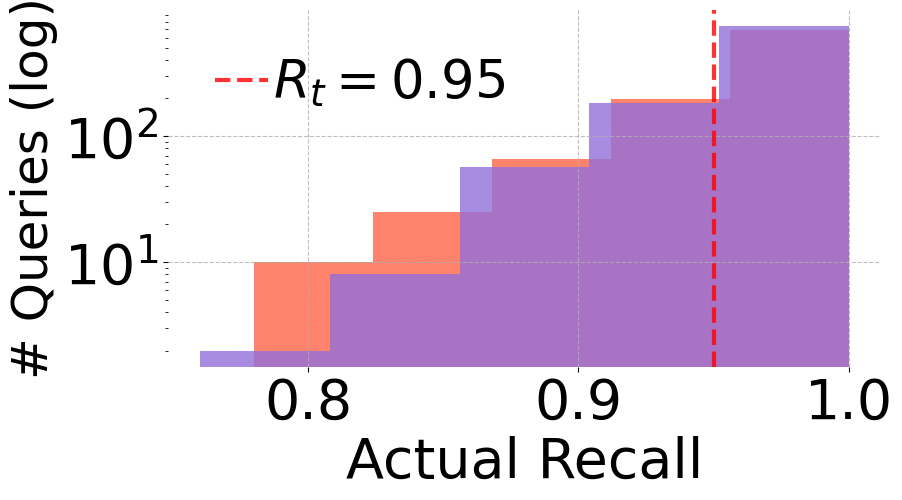

Saved figure to ./../../experiments/plots/darth_journal/no_guarantees_distribution_recalls_SIFT100M_k50_rt0.95.pdf


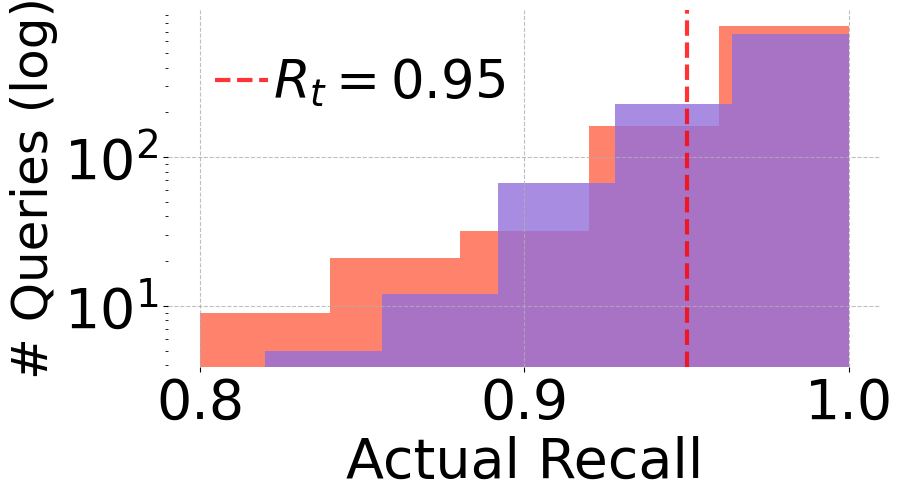

Saved figure to ./../../experiments/plots/darth_journal/no_guarantees_distribution_recalls_DEEP100M_k50_rt0.95.pdf


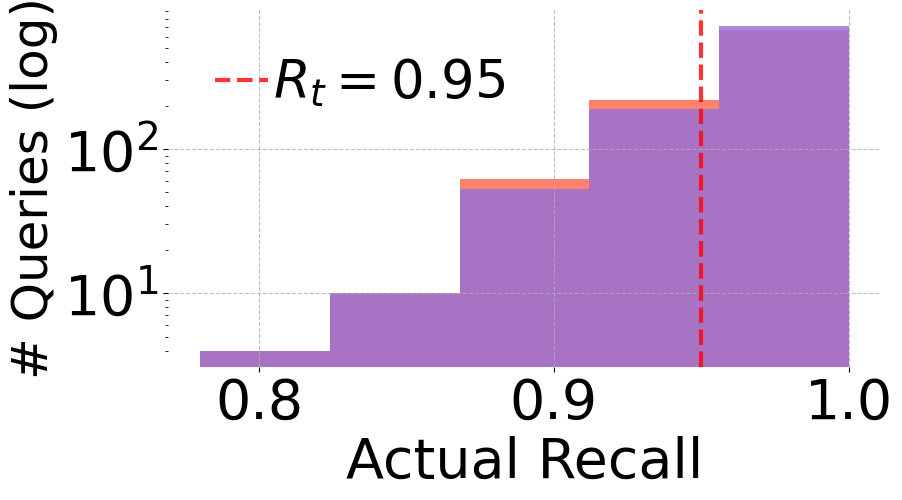

Saved figure to ./../../experiments/plots/darth_journal/no_guarantees_distribution_recalls_GLOVE100_k50_rt0.95.pdf


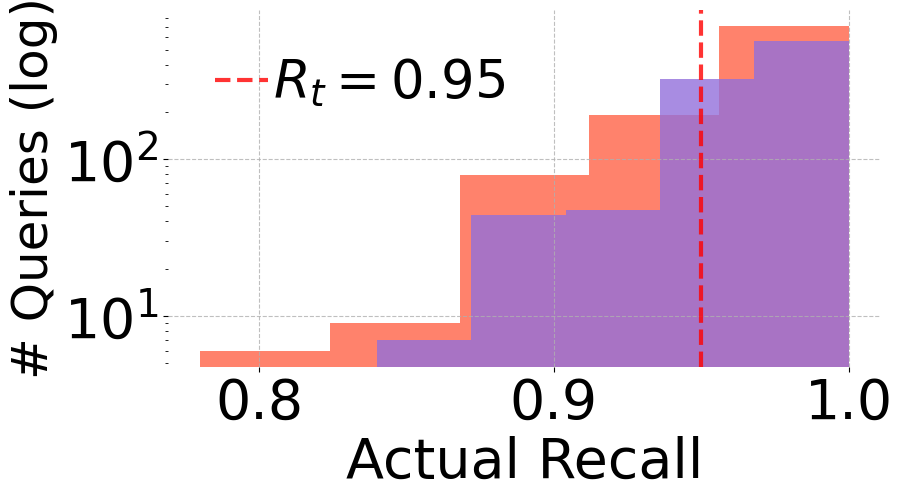

Saved figure to ./../../experiments/plots/darth_journal/no_guarantees_distribution_recalls_GIST1M_k50_rt0.95.pdf


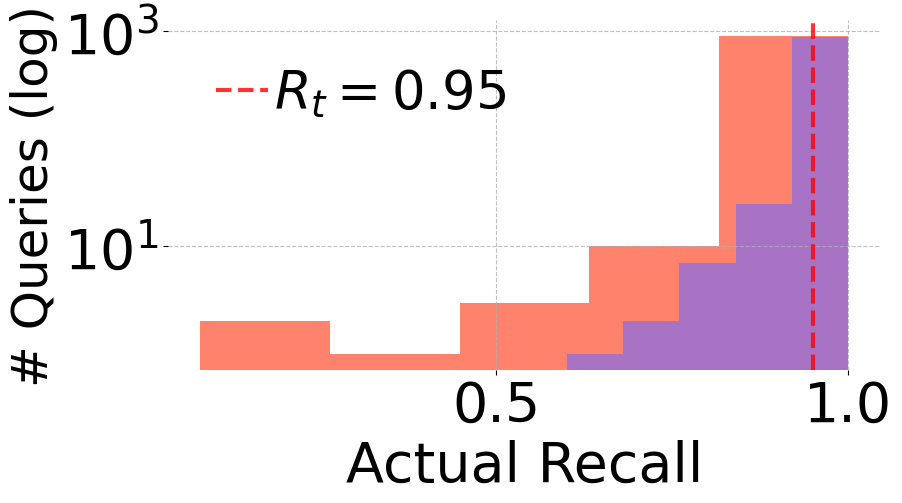

Saved figure to ./../../experiments/plots/darth_journal/no_guarantees_distribution_recalls_T2I100M_k50_rt0.95.pdf


In [16]:
generate_unified_plot = False  # <<< toggle here

# for each dataset and k value, a fig, with an ax for every
all_datasets = ["SIFT100M", "DEEP100M", "GLOVE100", "GIST1M", "T2I100M"]
all_k_values = [50]
recall_targets = [0.95]
distribution_measures = ["recalls"]

distribution_measure_labels = {
    "recalls": "Actual Recall",
    "dists": "Distance Calcs",
    "times": "Query Time (ms)",
}

low_quantiles = []#[0.1]
expected_coverages = []# [0.9]

models_to_test = ["darth", "darth+_classic"]
for exp_cov in expected_coverages:
    models_to_test += [f"darth+_classic_cov_{exp_cov}"]

for lq in low_quantiles:
    models_to_test += [f"darth+_quant_lq{lq}"]


for distribution_measure in distribution_measures:
    for ds_name in all_datasets:
        for k in all_k_values:

            # =========================
            # UNIFIED FIGURE
            # =========================
            if generate_unified_plot:
                plt.rcParams.update({'font.size': 11})
                fig, axs = plt.subplots(
                    nrows=1,
                    ncols=len(recall_targets),
                    figsize=(4 * len(recall_targets), 4)
                )

                if len(recall_targets) == 1:
                    axs = [axs]

                for irt, rt in enumerate(recall_targets):
                    ax = axs[irt]

                    for model_name in models_to_test:
                        values = results[ds_name][k][rt][model_name][distribution_measure]
                        avg = np.mean(values)
                        label = algorithm_conf[model_name]["label"]
                        color = algorithm_conf[model_name]["color"]

                        ax.hist(
                            values,
                            label=f"{label} | avg={avg:.2f}",
                            color=color,
                            alpha=0.6,
                            bins=5
                        )

                    ax.set_xlabel(distribution_measure)
                    ax.set_ylabel("# queries")
                    ax.set_title(f"Rt={rt}")
                    ax.grid(True)
                    ax.set_yscale("log")
                    ax.axvline(x=rt, color="black", linestyle="--")

                handles, labels = axs[0].get_legend_handles_labels()
                fig.legend(
                    handles,
                    labels,
                    loc="upper center",
                    ncol=len(models_to_test),
                    bbox_to_anchor=(0.5, 1.15)
                )

                fig.suptitle(f"{distribution_measure} | {ds_name} | k={k}")
                fig.tight_layout()

            # =========================
            # SEPARATE FIGURES + SEPARATE LEGEND
            # =========================
            else:
                plt.rcParams.update({'font.size': 40})
                legend_handles = None
                legend_labels = None

                for irt, rt in enumerate(recall_targets):
                    fig, ax = plt.subplots(figsize=(10, 6))

                    for model_name in models_to_test:
                        values = results[ds_name][k][rt][model_name][distribution_measure]
                        avg = np.mean(values)
                        label = algorithm_conf[model_name]["label"]
                        color = algorithm_conf[model_name]["color"]

                        h = ax.hist(
                            values,
                            #label=f"avg={avg:.2f}",
                            color=color,
                            alpha=0.8,
                            bins=5
                        )

                    ax.set_xlabel(distribution_measure_labels.get(distribution_measure, distribution_measure))
                    ax.set_ylabel("# Queries (log)", fontsize=36)
                    ax.grid(alpha=0.8, linestyle='--')
                    for spine in ax.spines.values():
                        spine.set_visible(False)
                
                    
                    # set xlim to be the rem minimum value:
                    if distribution_measure == "recalls":
                        ax.axvline(x=rt, color="red", linestyle="--", alpha=0.8, linewidth=3, label=r"$R_t=${}".format(rt))
                        rem_values = results[ds_name][k][rt]["rem"][distribution_measure]
                        rem_min = np.min(rem_values)
                        #ax.set_xlim(left=rem_min - 0.05)
                        ax.set_yscale("log")
                    ax.legend(fontsize=38, frameon=False, handletextpad=0.1, handlelength=1.0, columnspacing=0.3)   

                    # Capture legend handles once
                    if legend_handles is None:
                        legend_handles, legend_labels = ax.get_legend_handles_labels()

                    fig.tight_layout()
                    plt.show()
                    
                    pref = "guarantees" if len(expected_coverages) > 0 or len(low_quantiles) > 0 else "no_guarantees"
                    savepath = f"./../../experiments/plots/darth_journal/{pref}_distribution_{distribution_measure}_{ds_name}_k{k}_rt{rt}.pdf"
                    fig.savefig(savepath, bbox_inches='tight')
                    print(f"Saved figure to {savepath}")
                # ---- Legend-only figure ----
                #legend_fig = plt.figure(figsize=(4 * len(models_to_test), 1.5))
                #legend_fig.legend(
                #    legend_handles,
                #    legend_labels,
                #    loc="center",
                #    ncol=len(models_to_test)
                #)
                #legend_fig.tight_layout()


### Quality Measures

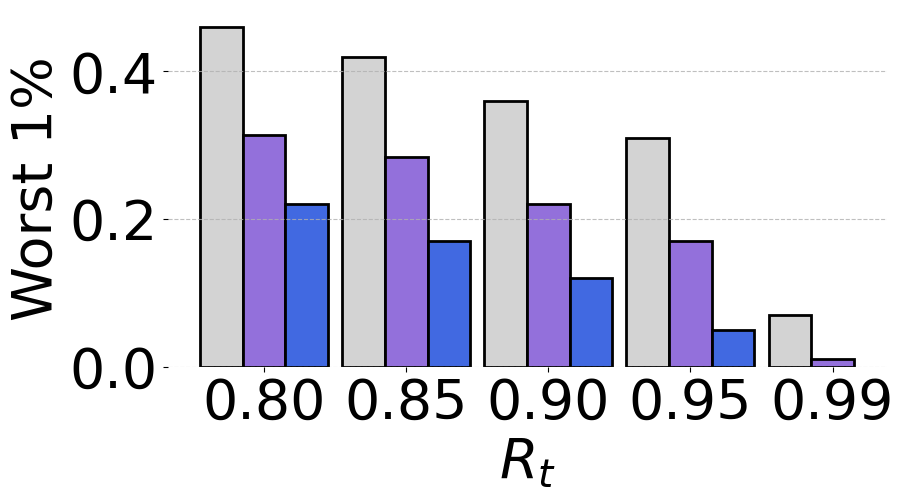

Saved figure to ./../../experiments/plots/darth_journal/guarantees_competitors_SIFT100M_k50_Worst1perc.pdf


<Figure size 900x90 with 0 Axes>

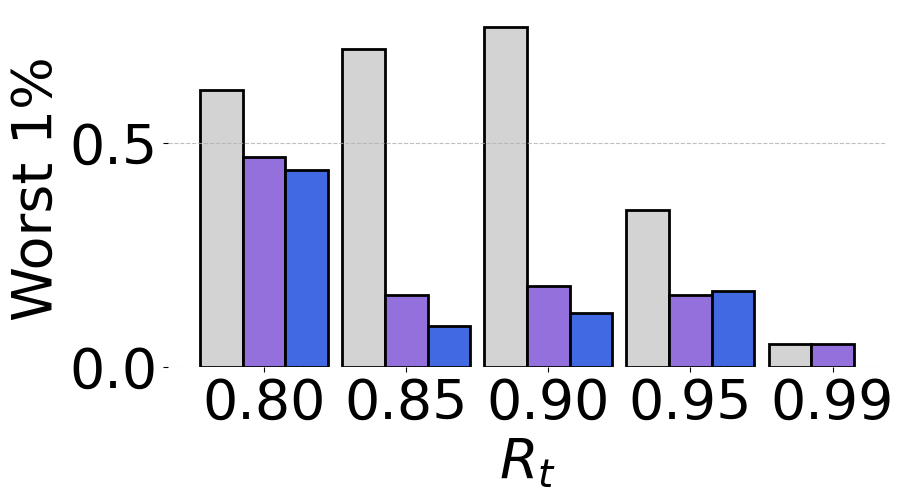

Saved figure to ./../../experiments/plots/darth_journal/guarantees_competitors_GLOVE100_k50_Worst1perc.pdf


<Figure size 900x90 with 0 Axes>

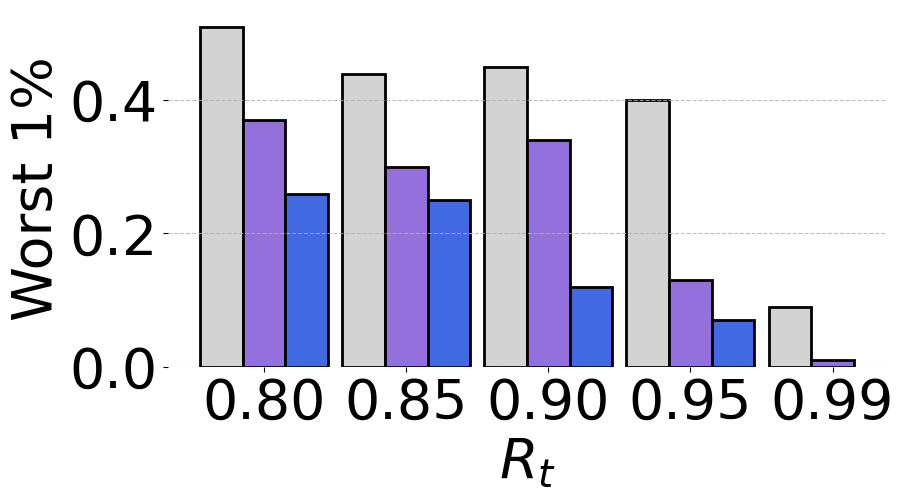

Saved figure to ./../../experiments/plots/darth_journal/guarantees_competitors_DEEP100M_k50_Worst1perc.pdf


<Figure size 900x90 with 0 Axes>

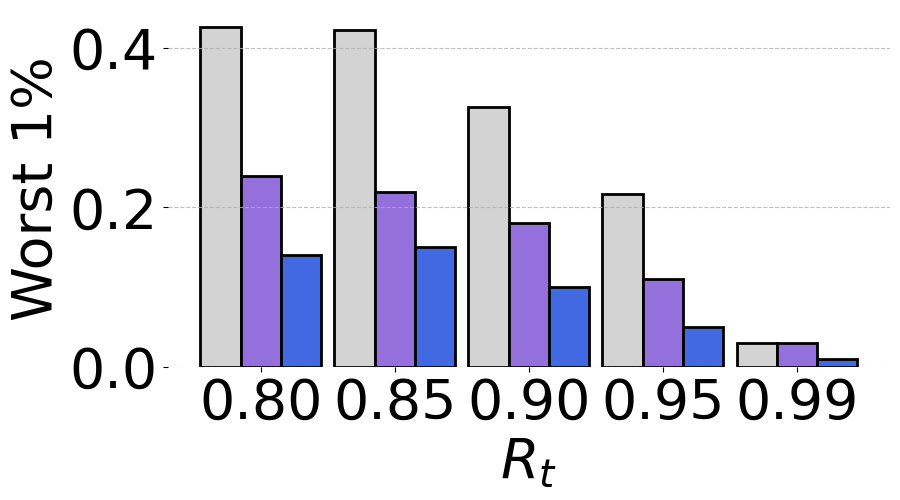

Saved figure to ./../../experiments/plots/darth_journal/guarantees_competitors_GIST1M_k50_Worst1perc.pdf


<Figure size 900x90 with 0 Axes>

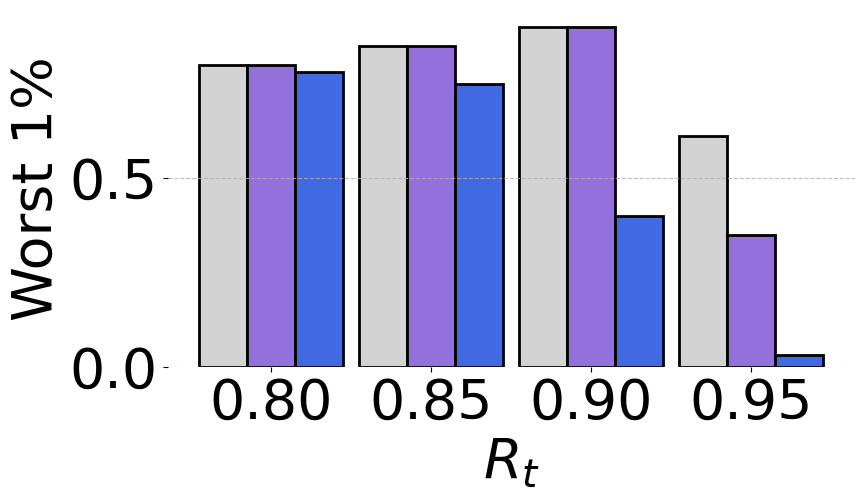

Saved figure to ./../../experiments/plots/darth_journal/guarantees_competitors_T2I100M_k50_Worst1perc.pdf


<Figure size 900x90 with 0 Axes>

In [26]:
all_datasets = ["SIFT100M", "GLOVE100", "DEEP100M", "GIST1M", "T2I100M"]
all_k_values = [50]
recall_targets = [0.80, 0.85, 0.9, 0.95, 0.99]
models_to_test = ["rem", "darth+_classic"]

expected_coverages = []#[0.9]
low_quantiles = [0.1]

measures_to_cmp = ["Worst1perc"]#["RQUT", "avgRecall", "RDE", "Dist"]


for exp_cov in expected_coverages:
    models_to_test += [f"darth+_classic_cov_{exp_cov}"]

for lq in low_quantiles:
    models_to_test += [f"darth+_quant_lq{lq}"]

generate_unified_plot = False
for ds_name in all_datasets:
    if ds_name == "T2I100M":
        recall_targets = [0.80, 0.85, 0.9, 0.95]
    else:
        recall_targets = [0.80, 0.85, 0.9, 0.95, 0.99]
        
    for mes in measures_to_cmp:

        if generate_unified_plot:
            plt.rcParams.update({'font.size': 11})
            # -----------------------------
            # Unified figure (subplots per k)
            # -----------------------------
            fig, axs = plt.subplots(
                nrows=1,
                ncols=len(all_k_values),
                figsize=(4 * len(all_k_values), 3),
                sharey=False,
            )

            if len(all_k_values) == 1:
                axs = [axs]

            bar_width = 0.16
            x = np.arange(len(recall_targets))

            legend_handles = None
            legend_labels = None

            for axi, k in enumerate(all_k_values):
                ax = axs[axi]

                for mi, model_to_test in enumerate(models_to_test):
                    model_values = [
                        results[ds_name][k][rt][model_to_test][mes]
                        for rt in recall_targets
                    ]
                    
                    # Scale by 10^(-3) if measure is Dist
                    if mes == "Dist":
                        model_values = [v * 1e-3 for v in model_values]

                    ax.bar(
                        x + mi * bar_width,
                        model_values,
                        width=bar_width,
                        color=algorithm_conf[model_to_test]["color"],
                        label=algorithm_conf[model_to_test]["label"],
                    )

                if legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()

                ax.set_xticks(x + bar_width * (len(models_to_test) - 1) / 2)
                ax.set_xticklabels(recall_targets)
                ax.set_xlabel("Rt")
                ax.set_title(f"k = {k}")
                ax.grid(True, axis="y")

                if axi == 0:
                    # Update y-label for Dist
                    ylabel = quality_measures[mes]["label"] + r" ($\times 10^{-3}$)" if mes == "Dist" else quality_measures[mes]["label"]
                    ax.set_ylabel(ylabel)

            fig.legend(
                legend_handles,
                legend_labels,
                loc="upper center",
                ncol=len(models_to_test),
                frameon=False,
                bbox_to_anchor=(0.5, 1.15),
            )

            fig.suptitle(f"{ds_name} | Measure: {mes}")
            fig.tight_layout(rect=[0, 0, 1, 0.90])
            plt.show()

        else:
            # ---------------------------------
            # Separate figure per k
            # + standalone legend figure
            # ---------------------------------
            legend_handles = None
            legend_labels = None

            for k in all_k_values:
                plt.rcParams.update({'font.size': 40})
                fig, ax = plt.subplots(figsize=(10, 6))

                bar_width = 0.3
                x = np.arange(len(recall_targets))

                for mi, model_to_test in enumerate(models_to_test):
                    model_values = [
                        results[ds_name][k][rt][model_to_test][mes]
                        for rt in recall_targets
                    ]
                    
                    # Scale by 10^(-3) if measure is Dist
                    if mes == "Dist":
                        model_values = [v * 1e-3 for v in model_values]

                    ax.bar(
                        x + mi * bar_width,
                        model_values,
                        width=bar_width,
                        color=algorithm_conf[model_to_test]["color"],
                        label=algorithm_conf[model_to_test]["label"],
                        edgecolor="black",
                        linewidth=2,
                    )

                if legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()
                    
                if mes == "RQUT":
                    # add a horizontal line at y=0.1 (to show the guarantee:
                    ax.axhline(y=0.1, color='red', linestyle='--', linewidth=3, label='RQUT Guarantee (0.1)')
                    # also: make sure that 0.1 appears as a y-tick:
                    #current_yticks = ax.get_yticks().tolist()
                    #if 0.1 not in current_yticks:
                    #    current_yticks.append(0.1)
                    #    current_yticks = sorted(current_yticks)
                    #    ax.set_yticks(current_yticks)
                    y_tics = ax.get_yticks().tolist()
                    ax.set_yticks(sorted(y_tics + [0.1]))
                
                if mes == "avgRecall":
                    ax.set_ylim(0.78, 1.0)
                    ax.set_yticks([0.80, 0.85, 0.90, 0.95, 0.99])
                    ax.set_yticklabels(["0.80", "0.85", "0.90", "0.95", "0.99"])
                
                ax.set_xticks(x + bar_width * (len(models_to_test) - 1) / 2)
                ax.set_xticklabels([f"{rt:.2f}" for rt in recall_targets])
                ax.set_xlabel(r"$R_t$")
                #ax.set_title(f"{ds_name} | {mes} | k = {k}")
                
                # Update y-label for Dist
                ylabel = quality_measures[mes]["label"]
                if mes == "Dist":
                    ylabel += r" ($10^{-3}$)"
                ax.set_ylabel(ylabel)
                
                ax.grid(alpha=0.8, axis='y', linestyle='--')
                for spine in ax.spines.values():
                    spine.set_visible(False)
                    

                plt.tight_layout()
                plt.show()
                
                prefix = "guarantees" if len(expected_coverages) > 0 or len(low_quantiles) > 0 else "no_guarantees"
                #methods = "darth" if 
                # if only darth models are compared, method="darth", else "competitors":
                method = "darth" if all(["darth" in m for m in models_to_test]) else "competitors"
                savepath = f"./../../experiments/plots/darth_journal/{prefix}_{method}_{ds_name}_k{k}_{mes}.pdf"
                fig.savefig(savepath, bbox_inches='tight')
                print(f"Saved figure to {savepath}")

            # -----------------------------
            # Standalone legend figure
            # -----------------------------
            fig_legend = plt.figure(figsize=(3 * len(models_to_test), 0.9))
            fig_legend.legend(
                legend_handles,
                legend_labels,
                loc="center",
                ncol=len(models_to_test),
                frameon=False,
            )
            fig_legend.tight_layout()
            plt.show()

#### Average metrics (recall, rqut, rde, running time in ms)

In [ ]:
all_datasets = ["SIFT100M", "GLOVE100", "DEEP100M"]
all_k_values = [10, 25, 50, 75, 100]
recall_targets = [0.80, 0.85, 0.9, 0.95, 0.99]
measures_to_cmp = ["avgRecall", "RQUT", "RDE", "QPS", "Worst1perc", "Dist", "avgError"]

expected_coverages = [] #[0.8, 0.9]
quantile_pairs = [[0.1, 0.9]]
s = 1000

models_to_test = ["baseline", "rem", "laet", "darth", "darth+_classic"]
for exp_cov in expected_coverages:
    models_to_test += [f"darth+_classic_cov_{exp_cov}"]
    
for quantile_pair in quantile_pairs:
    lq, uq = quantile_pair[0], quantile_pair[1]
    models_to_test += [f"darth+_quant_lq{lq}_uq{uq}"]

darth_json_pi_data = json.load(open("../../experiments/generated_json/final_heuristic_adaptive_recommendations_params_ipidiv2_mpidiv10.json"))
rem_data = json.load(open(f"{DARTH_JSON_DIRECTORY}/classic_hnsw_tuning_results_memoryFalse_validationSize1000.json"))

results = {}
for ds_name in all_datasets:
    darth_plus_json_pi_data = json.load(open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_pi_params_{ds_name}.json")))
    
    results[ds_name] = {}
    M = DATASET_PARAMS[ds_name]["M"]
    efC = DATASET_PARAMS[ds_name]["efC"]
    efS = DATASET_PARAMS[ds_name]["efS"]

    for k in all_k_values:
        results[ds_name][k] = {}
        for r_target in recall_targets:
            darth_ipi, darth_mpi = darth_json_pi_data[ds_name][str(k)][f"{float(r_target):.2f}"]["ipi"], darth_json_pi_data[ds_name][str(k)][f"{float(r_target):.2f}"]["mpi"]
            darth_plus_ipi, darth_plus_mpi = darth_plus_json_pi_data[str(k)][f"{float(r_target)}"]["ipi"], darth_plus_json_pi_data[str(k)][f"{float(r_target)}"]["mpi"]
            f_r_target = float(r_target)
                        
            no_early_stop_df = pd.read_csv(f"../../experiments/results/no-early-stop/testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{s}.txt", usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r", "RDE", "TDR", "NRS"])
            no_early_stop_df = no_early_stop_df[no_early_stop_df["r"] >= f_r_target]              
                        
            rem_df = pd.read_csv(get_rem_results_filename(M, efC, rem_data[ds_name][str(k)][f"{float(r_target)}"]["min_efS"], s, ds_name, k, r_target), usecols=["qid", "elaps_ms", "dists", "r", "RDE", "TDR", "NRS"])
            darth_df = pd.read_csv(get_darth_results_filename(M, efC, efS, s, ds_name, k, r_target, darth_ipi, darth_mpi), usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r_actual", "r_predicted", "r_predictor_calls", "r_predictor_time_ms", "RDE", "TDR", "NRS"])
            baseline_df = pd.read_csv(get_baseline_results_filename(M, efC, efS, s, ds_name, k, r_target), usecols=["qid", "elaps_ms", "dists", "r", "RDE", "TDR", "NRS"])
            laet_df = pd.read_csv(get_laet_results_filename(M, efC, efS, s, ds_name, k, r_target), usecols=["qid", "elaps_ms", "dists", "predicted_distance_calcs", "r", "RDE", "TDR", "NRS"])
            darth_plus_classic_df = pd.read_csv(get_darth_plus_classic_regression_results_filename(M, efC, efS, s, ds_name, k, r_target, darth_plus_ipi, darth_plus_mpi), usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r_actual", "r_lower", "r_upper", "r_predictor_calls", "r_predictor_time_ms", "RDE", "TDR", "NRS"])
            
            darth_plus_classic_cover_models_dfs = {}
            for expected_coverage in expected_coverages:
                darth_plus_classic_cover_models_dfs[expected_coverage] = pd.read_csv(get_darth_plus_classic_regression_conformal_results_filename(M, efC, efS, s, ds_name, k, r_target, darth_plus_ipi, darth_plus_mpi, expected_coverage), usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r_actual", "r_lower", "r_upper", "r_predictor_calls", "r_predictor_time_ms", "RDE", "TDR", "NRS"])
            
            darth_plus_quantile_models = {}
            for quantile_pair in quantile_pairs:
                lq, uq = quantile_pair[0], quantile_pair[1]
                darth_plus_quantile_models[f"lq{lq}_uq{uq}"] = pd.read_csv(get_darth_plus_quantile_regression_results_filename(M, efC, efS, s, ds_name, k, r_target, darth_plus_ipi, darth_plus_mpi, lq, uq), usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r_actual", "r_lower", "r_upper", "r_predictor_calls", "r_predictor_time_ms", "RDE", "TDR", "NRS"])
            
            #darth_plus_quantile_cover_models = {}
            #for quantile_pair in quantile_pairs:
            #    for expected_coverage in expected_coverages:
            #        darth_plus_quantile_cover_models[(quantile_pair, expected_coverage)] = ...
            
            all_models = {
                "baseline": baseline_df,
                "rem": rem_df,
                "laet": laet_df,
                "darth": darth_df,
                "darth+_classic": darth_plus_classic_df,
            }
            
            for expected_coverage, model in darth_plus_classic_cover_models_dfs.items():
                all_models[f"darth+_classic_cov_{expected_coverage}"] = model
                
            for quantile_pair, model in darth_plus_quantile_models.items():
                all_models[f"darth+_quant_{quantile_pair}"] = model

            #for (quantile_pair, expected_coverage), model in darth_plus_quantile_cover_models.items():
            #    models_to_evaluate[f"darth+_quantile_{quantile_pair}_cover_{expected_coverage}"] = model
                        
            results[ds_name][k][r_target] = {}
            for model_name in models_to_test:
                model_results_df = all_models[model_name]
                results[ds_name][k][r_target][model_name] = {}
                for mes in measures_to_cmp:
                    recall_col = "r" if "r" in model_results_df.columns else "r_actual"
                    mes_value = quality_measures[mes]["calculator"](model_results_df, s, r_target, recall_col)
                    results[ds_name][k][r_target][model_name][mes] = mes_value        

In [ ]:
all_datasets = ["SIFT100M"]
all_k_values = [50]
recall_targets = [0.80, 0.85, 0.9, 0.95, 0.99]
models_to_test = ["darth+_classic"]

expected_coverages = [] #[0.8, 0.9]
quantile_pairs = [[0.1, 0.9]]

measures_to_cmp = ["avgRecall",  "Dist", "RQUT", "RDE", "QPS", "Worst1perc", "avgError"]
for exp_cov in expected_coverages:
    models_to_test += [f"darth+_classic_cov_{exp_cov}"]
    
for quantile_pair in quantile_pairs:
    lq, uq = quantile_pair[0], quantile_pair[1]
    models_to_test += [f"darth+_quant_lq{lq}_uq{uq}"]

for ds_name in all_datasets:
    for k in all_k_values:
        fig, axs = plt.subplots(
            nrows=math.ceil(len(measures_to_cmp) / 4),
            ncols=4,
            figsize=(4 * 4, 3*math.ceil(len(measures_to_cmp) / 4))
        )

        if len(measures_to_cmp) == 1:
            axs = [axs]
        axs = axs.flatten()

        bar_width = 0.18
        x = np.arange(len(recall_targets))

        for axi, mes in enumerate(measures_to_cmp):
            for mi, model_to_test in enumerate(models_to_test):
                model_values = [results[ds_name][k][rt][model_to_test][mes] for rt in recall_targets]
                axs[axi].bar(x + mi * bar_width, model_values, width=bar_width, label=model_to_test)

            axs[axi].set_xticks(x + bar_width * (len(models_to_test) - 1) / 2)
            axs[axi].set_xticklabels(recall_targets)
            axs[axi].set_xlabel("Rt")
            axs[axi].set_ylabel(mes)
            axs[axi].set_title(mes)
            axs[axi].grid(True, axis="y")

        handles, labels = axs[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=len(models_to_test),
            bbox_to_anchor=(0.23, 1.00)
        )

        fig.suptitle(f"{ds_name} | k={k}")
        fig.tight_layout()


## Inner product experiments

In [5]:
inner_product_dataset_params = {
    "GLOVE100": {
        "M": 32,
        "efC": 500,
        "efS": 1000
    },
    "GIST1M": {
        "M": 64,
        "efC": 500,
        "efS": 1000
    },
    "SIFT10M":{
        "M": 16,
        "efC": 500,
        "efS": 500
    },
    "DEEP10M":{
        "M": 16,
        "efC": 500,
        "efS": 750
    },
    "T2I10M":{
        "M": 40,
        "efC": 1000,
        "efS": 1500
    }
}

### Check the achieved model prediction on validation and testing (MSE, MAE, R2)

In [ ]:
all_k_values = [10, 25, 50, 75, 100]
all_datasets = ["T2I10M", "SIFT10M", "DEEP10M", "GIST1M", "GLOVE100"]
n_estimators = 100
data = "testing"
metric = "inner-product"

results = {}
for ds_name in all_datasets:
    M = inner_product_dataset_params[ds_name]["M"]
    efC = inner_product_dataset_params[ds_name]["efC"]
    efS = inner_product_dataset_params[ds_name]["efS"]
    
    results[ds_name] = {}
    
    #darth_train_stats = {}
    #with open(f"./../../experiments/generated_json/training_results_{ds_name}_{metric}.json", "r") as f:
    #    darth_train_stats = json.load(f)
    
    darth_plus_train_stats = {}
    with open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"hnsw_{ds_name}_M{M}_efC{efC}_efS{efS}_training_results_{metric}.json"),"r") as f:
        darth_plus_train_stats = json.load(f)
    
    print(darth_plus_train_stats)
    
    for k in all_k_values:
        data_path = ""
        if data == "testing":
            data_path = get_testing_dataset_name_inner_product(M, efC, efS, 1000, ds_name, k)
        elif data == "validation":
           data_path = get_validation_dataset_name_inner_product(M, efC, efS, 1000, ds_name, k)
        else:
            raise ValueError("Data must be either 'testing' or 'validation'")
        
        darth_plus_with_dims_model = lgb.Booster(
            model_file=os.path.join(
                DARTH_PLUS_MODEL_DIRECTORY,
                f"{ds_name}_M{M}_efC{efC}_efS{efS}_k{k}_darth_and_query_dims_regr_nest{n_estimators}_{metric}.txt"
            )
        )

        darth_plus_dims_training_time = darth_plus_train_stats["training_results"][f"k{k}"]["darth_and_query_dims"][f"nest{n_estimators}"]["regression"]["train_time"]
        
        data_df = dd_load_as_pd(data_path, COLUMNS_TO_LOAD)
        y = data_df["r"]
        X_test = data_df[FEATURE_CLASSES["darth_and_query_dims"]]
        
        y_pred = darth_plus_with_dims_model.predict(X_test)
        mae = mean_absolute_error(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        
        print(f"{ds_name} k {k} (mae: {mae:.3f}, mse: {mse:.3f}, r2: {r2:.2f})")
        results[ds_name][k] = {
            "mae": mae,
            "mse": mse,
            "r2": r2,
            "train_time": darth_plus_dims_training_time,
            "inference_time": -1,
        }

    

In [ ]:
all_datasets = ["SIFT10M", "GLOVE100", "DEEP10M", "GIST1M", "T2I10M"]
all_k_values = [10, 25, 50, 75, 100]

all_measures = ["mae", "mse", "r2"]

measure_labels = {
    "mae": r"$MAE \text{ } (10^2)$",
    "mse": r"$MSE \text{ } (10^2)$",
    "r2": r"$R^2$",
}

generate_unified_plot = False

if generate_unified_plot:
    fig, axs = plt.subplots(
        nrows=1,
        ncols=len(all_measures),
        figsize=(4 * len(all_measures), 3),
        sharey=False,
    )
    
    plt.rcParams.update({"font.size": 11})


    if len(all_measures) == 1:
        axs = [axs]

    axs = axs.flatten()

    legend_handles = None
    legend_labels = None

    for imes, mes in enumerate(all_measures):
        bar_width = 0.16
        x = np.arange(len(all_k_values))
        ax = axs[imes]

        for mi, ds_name in enumerate(all_datasets):
            ds_values = [
                results[ds_name][k][mes]
                for k in all_k_values
            ]
            
            # Scale MAE and MSE by 100
            if mes in ["mae", "mse"]:
                ds_values = [v * 100 for v in ds_values]

            ax.bar(
                x + mi * bar_width,
                ds_values,
                width=bar_width,
                color=DATASET_PARAMS[ds_name]["color"],
                label=DATASET_PARAMS[ds_name]["label"],
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_xticks(x + bar_width * (len(all_datasets) - 1) / 2)
        ax.set_xticklabels(all_k_values)
        ax.set_xlabel("k")
        ax.set_title(measure_labels[mes])
        ax.set_ylabel(measure_labels[mes])
        ax.grid(True, axis="y")

    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=len(all_datasets),
        frameon=False,
        bbox_to_anchor=(0.5, 1.15),
    )

    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

else:
    plt.rcParams.update({"font.size": 40})
    legend_handles = None
    legend_labels = None

    for mes in all_measures:
        fig, ax = plt.subplots(figsize=(10, 6))

        bar_width = 0.15
        x = np.arange(len(all_k_values))

        for mi, ds_name in enumerate(all_datasets):
            ds_values = [
                results[ds_name][k][mes]
                for k in all_k_values
            ]
            
            # Scale MAE and MSE by 100
            if mes in ["mae", "mse"]:
                ds_values = [v * 100 for v in ds_values]

            ax.bar(
                x + mi * bar_width,
                ds_values,
                width=bar_width,
                color=DATASET_PARAMS[ds_name]["color"],
                label=DATASET_PARAMS[ds_name]["label"],
                linewidth=2,
                edgecolor="black"
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_xticks(x + bar_width * (len(all_datasets) - 1) / 2)
        ax.set_xticklabels(all_k_values)
        ax.set_xlabel("k")
        ax.set_ylabel(measure_labels[mes])
        ax.grid(alpha=0.8, axis='y', linestyle='--')
        for spine in ax.spines.values():
            spine.set_visible(False)

        plt.tight_layout()
        plt.show()
        save_path = f"./../../experiments/plots/darth_journal/inner_product_prediction_{mes}.pdf"
        fig.savefig(save_path, bbox_inches='tight')
        print(f"Saved figure to {save_path}")

    # -----------------------------
    # Standalone legend figure
    # -----------------------------
    fig_legend = plt.figure(figsize=(3 * len(all_datasets), 0.9))
    fig_legend.legend(
        legend_handles,
        legend_labels,
        loc="center",
        ncol=len(all_datasets),
        frameon=False,
    )
    fig_legend.tight_layout()
    plt.show()

### Get mpi and ipi parameters for end-to-end experiments

In [ ]:
all_datasets = ["GLOVE100", "SIFT10M", "DEEP10M", "GIST1M", "T2I10M"]
all_k_values = [10, 25, 50, 75, 100]
target_recalls = [0.80, 0.85, 0.90, 0.95, 0.99]
metric = "inner-product"
for ds_name in all_datasets:
    pi_params = {}
    for k in all_k_values:
        M = inner_product_dataset_params[ds_name]["M"]
        efC = inner_product_dataset_params[ds_name]["efC"]
        efS = inner_product_dataset_params[ds_name]["efS"]
        data_df = dd_load_as_pd(f"/data/mchatzakis/et_training_data/darth_plus/darth-plus-training/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{10000}_{metric}.txt", COLUMNS_TO_LOAD)   
        pi_params[k] = dp_find_pi_params(data_df, target_recalls=target_recalls)
    
    for k in all_k_values:
        print(f"{ds_name}_tuples_k{k}=(")
        for rt in target_recalls:
            ipi = pi_params[k][rt]["ipi"]
            mpi = pi_params[k][rt]["mpi"]
            print(f"    \"{rt:.2f} {ipi} {mpi}\"")
        print(")")  
    print()

    json.dump(pi_params, open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_pi_params_{ds_name}_{metric}.json"), "w"), indent=4)
    


### Calculate achieved recalls for inner product

In [ ]:
all_datasets = ["SIFT10M", "GLOVE100", "DEEP10M", "GIST1M", "T2I10M"]
all_k_values = [10, 25, 50, 75, 100]
recall_targets = [0.80, 0.85, 0.9, 0.95, 0.99]
metric = "inner-product"

results = {}
for ds_name in all_datasets:
    darth_plus_json_pi_data = json.load(open(os.path.join(DARTH_PLUS_JSON_DIRECTORY, f"darth_plus_pi_params_{ds_name}_{metric}.json")))
    
    results[ds_name] = {}
    M = inner_product_dataset_params[ds_name]["M"]
    efC = inner_product_dataset_params[ds_name]["efC"]
    efS = inner_product_dataset_params[ds_name]["efS"]

    for k in all_k_values:
        results[ds_name][k] = {}
        for r_target in recall_targets:
            darth_plus_ipi, darth_plus_mpi = darth_plus_json_pi_data[str(k)][f"{float(r_target)}"]["ipi"], darth_plus_json_pi_data[str(k)][f"{float(r_target)}"]["mpi"]
            f_r_target = float(r_target)
                        
            #no_early_stop_df = pd.read_csv(f"../../experiments/results/no-early-stop/testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{1000}_{metric}.txt", usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r", "RDE", "TDR", "NRS"])
            #no_early_stop_df = no_early_stop_df[no_early_stop_df["r"] >= f_r_target]              
            
            fname = f"../../experiments/results/darth_journal/darth-plus-testing/{ds_name}/k{k}/M{M}_efC{efC}_efS{efS}_qs{1000}_tr{float(r_target):.2f}_ipi{darth_plus_ipi}_mpi{darth_plus_mpi}_noconf_{metric}.txt"
            darth_plus_classic_df = pd.read_csv(fname, usecols=["qid", "step", "dists", "inserts", "elaps_ms", "r_actual", "r_lower", "r_upper", "r_predictor_calls", "r_predictor_time_ms", "RDE", "TDR", "NRS"])

            avg_recall = np.mean(darth_plus_classic_df["r_actual"].values)
            results[ds_name][k][r_target] = {
                "avgRecall": avg_recall
            }

In [ ]:
all_datasets = ["SIFT10M", "GLOVE100", "DEEP10M", "GIST1M", "T2I10M"]
all_k_values = [10, 25, 50, 75, 100]

recall_targets = [0.80, 0.85, 0.9, 0.95, 0.99]

fig, axs = plt.subplots(
    nrows=1,
    ncols=len(all_datasets),
    figsize=(4 * len(all_datasets), 3),
    sharey=False
)

if len(all_datasets) == 1:
    axs = [axs]

axs = axs.flatten()

for ids, ds_name in enumerate(all_datasets):
    bar_width = 0.16
    x = np.arange(len(recall_targets))
    ax = axs[ids]

    for ik, k in enumerate(all_k_values):
        ds_values = [
            results[ds_name][k][rt]["avgRecall"]
            for rt in recall_targets
        ]

        ax.bar(
            x + ik * bar_width,
            ds_values,
            width=bar_width,
            #color=DATASET_PARAMS[ds_name]["color"],
            label=f"k={k}"
        )

        ax.set_xticks(x + bar_width * (len(all_k_values) - 1) / 2)
        ax.set_xticklabels(recall_targets)
        ax.set_xlabel("Recall Target")
        ax.set_title(f"{ds_name}")
        ax.grid(True, axis="y")
        ax.set_ylabel("Actual Recall")
        ax.set_ylim(0.75, 1.02)
        ax.set_yticks([0.75, 0.80, 0.85, 0.90, 0.95, 1.0])

        handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(all_k_values),
    bbox_to_anchor=(0.5, 1.15)
)

fig.suptitle(f"")
fig.tight_layout()


In [ ]:
all_datasets = ["SIFT10M", "GLOVE100", "DEEP10M", "GIST1M", "T2I10M"]
all_k_values = [50, 100]
recall_targets = [0.80, 0.85, 0.9, 0.95, 0.99]

generate_unified_plot = False

if generate_unified_plot:
    # -----------------------------
    # Unified figure (subplots per k)
    # -----------------------------
    fig, axs = plt.subplots(
        nrows=1,
        ncols=len(all_k_values),
        figsize=(4 * len(all_k_values), 3),
        sharey=False,
    )

    if len(all_k_values) == 1:
        axs = [axs]

    axs = axs.flatten()

    legend_handles = None
    legend_labels = None

    for ik, k in enumerate(all_k_values):
        bar_width = 0.15
        x = np.arange(len(recall_targets))
        ax = axs[ik]

        for ids, ds_name in enumerate(all_datasets):
            ds_values = [
                results[ds_name][k][rt]["avgRecall"]
                for rt in recall_targets
            ]

            ax.bar(
                x + ids * bar_width,
                ds_values,
                width=bar_width,
                label=DATASET_PARAMS[ds_name]["label"],
                color=DATASET_PARAMS[ds_name]["color"],
                alpha=0.8,
                linewidth=2,
                edgecolor="black",
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_xticks(x + bar_width * (len(all_datasets) - 1) / 2)
        ax.set_xticklabels(recall_targets)
        ax.set_xlabel("Recall Target")
        ax.set_title(f"k={k}")
        ax.grid(True, axis="y")
        ax.set_ylabel("Actual Recall")
        ax.set_ylim(0.75, 1.02)
        ax.set_yticks([0.75, 0.80, 0.85, 0.90, 0.95, 1.0])

    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=len(all_datasets),
        frameon=False,
        bbox_to_anchor=(0.5, 1.15),
    )

    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

else:
    # ---------------------------------
    # Separate figure per k
    # + standalone legend figure
    # ---------------------------------
    plt.rcParams.update({"font.size": 40})

    legend_handles = None
    legend_labels = None

    for k in all_k_values:
        fig, ax = plt.subplots(figsize=(10, 6))

        bar_width = 0.15
        x = np.arange(len(recall_targets))

        for ids, ds_name in enumerate(all_datasets):
            ds_values = [
                results[ds_name][k][rt]["avgRecall"]
                for rt in recall_targets
            ]

            ax.bar(
                x + ids * bar_width,
                ds_values,
                width=bar_width,
                label=DATASET_PARAMS[ds_name]["label"],
                color=DATASET_PARAMS[ds_name]["color"],
                alpha=0.8,
                linewidth=2,
                edgecolor="black",
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_xticks(x + bar_width * (len(all_datasets) - 1) / 2)
        #ax.set_title(f"k={k}")
        ax.set_yticks([float(r) for r in [0.80, 0.85, 0.90, 0.95, 0.99]])
        ax.set_xlabel(r"$R_t$")
        ax.set_ylabel("Actual Recall")
        ax.set_xticklabels([str(t) for t in recall_targets])
        ax.grid(alpha=0.8, axis='y', linestyle='--')
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_ylim(0.78, 1.00)

        plt.tight_layout()
        plt.show()
        
        save_path = f"./../../experiments/plots/darth_journal/inner_product_actual_recall_k{k}.pdf"
        fig.savefig(save_path, bbox_inches='tight')
        print(f"Saved figure to {save_path}")

    # -----------------------------
    # Standalone legend figure
    # -----------------------------
    #fig_legend = plt.figure(figsize=(3 * len(all_datasets), 0.9))
    #fig_legend.legend(
    #    legend_handles,
    #    legend_labels,
    #    loc="center",
    #    ncol=len(all_datasets),
    #    frameon=False,
    #)
    #fig_legend.tight_layout()
    #plt.show()
